In [544]:
import os
import sys
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch, Ellipse, Rectangle
import importlib
import pandas as pd
import numpy as np
from sklearn.metrics import pairwise_distances, silhouette_score
import warnings
import statsmodels.api as sm

#This block only important for running as script
# script_dir = os.path.dirname(os.path.abspath(__file__))
# mariposa_dir = os.path.dirname(script_dir)
# utils_dir = os.path.join(mariposa_dir, 'utils')
# sys.path.append(utils_dir)
# sys.path.append(mariposa_dir)

from scipy.spatial.distance import euclidean, mahalanobis, cityblock

#import utils
from utils import analysis, plot, metadata

importlib.reload(analysis)
importlib.reload(plot)

<module 'utils.plot' from '/Users/snewbank/PycharmProjects/MARIPoSA/utils/plot.py'>

In [545]:
config_paths=["/Users/snewbank/Behavior/MARIPOSA_test/240827_BSOID-test/config_PS2.yaml",
              "/Users/snewbank/Behavior/MARIPOSA_test/240904_VAME-full/config_PS2.yaml",
              "/Users/snewbank/Behavior/MARIPOSA_test/240901_KPMS-full/config_PS2.yaml"]

save_paths=["/Users/snewbank/Desktop/committeemtg/pose/bsoid/",
            "/Users/snewbank/Desktop/committeemtg/pose/vame/",
            "/Users/snewbank/Desktop/committeemtg/pose/kpms/"]

dset=2
config_path=config_paths[dset]
save_path=save_paths[dset]
save=False

#Load config
config = metadata.load_project(config_path)

done with ['BINARY_2023-05-09_17-41-11_bf01_nal10k10.csv', '2023-05-09_17-41-11_bf01_nal10k10DLC_resnet101_all_pose_vidsJul17shuffle1_500000.csv']
done with ['BINARY_13-39-15_bm01_k25.csv', '2023-05-30_13-39-15_bm01_k25DLC_resnet101_all_pose_vidsJul17shuffle1_500000.csv']
done with ['BINARY_2024-05-09_13-38-52_bf33_d15.csv', '2024-05-09_13-38-52_bf33_d15DLC_resnet101_all_pose_vidsJul17shuffle1_500000.csv']
done with ['BINARY_1_2023-05-31_12-02-23_bf02_coc.csv', '2023-05-31_12-02-23_bf02_cocDLC_resnet101_all_pose_vidsJul17shuffle1_500000.csv']
done with ['BINARY_2023-06-15_19-15-24_bm04_nalket.csv', '2023-06-15_19-15-24_bm04_nalketDLC_resnet101_all_pose_vidsJul17shuffle1_500000.csv']
done with ['BINARY_2023-06-15_17-16-18_bm01_k5iv.csv', '2023-06-15_17-16-18_bm01_k5ivDLC_resnet101_all_pose_vidsJul17shuffle1_500000.csv']
done with ['BINARY_2023-06-09_18-18-49_bm02_k25.csv', '2023-06-09_18-18-49_bm02_k25DLC_resnet101_all_pose_vidsJul17shuffle1_500000.csv']
done with ['BINARY_2023-07-08_15

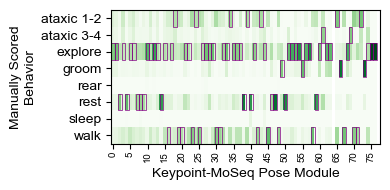

In [185]:
# labels_df = analysis.get_module_labels(config, 0, 1200, subgroups = "all")
# BORIS_to_pose_mat, BORIS_to_pose_mat_normalized, loss = analysis.BORIS_to_pose(config)
# plot.BORIS_to_pose_matrix_plot(config, BORIS_to_pose_mat_normalized, figW=4, figH=2, cmap="Greens",outline_top_match=True)
# if save:
#     plt.savefig(save_path+"boris.png",dpi=500)

done with ['BINARY_2023-05-09_17-41-11_bf01_nal10k10.csv', '2023-05-09_17-41-11_bf01_nal10k10DLC_resnet101_all_pose_vidsJul17shuffle1_500000.csv']
done with ['BINARY_13-39-15_bm01_k25.csv', '2023-05-30_13-39-15_bm01_k25DLC_resnet101_all_pose_vidsJul17shuffle1_500000.csv']
done with ['BINARY_2024-05-09_13-38-52_bf33_d15.csv', '2024-05-09_13-38-52_bf33_d15DLC_resnet101_all_pose_vidsJul17shuffle1_500000.csv']
done with ['BINARY_1_2023-05-31_12-02-23_bf02_coc.csv', '2023-05-31_12-02-23_bf02_cocDLC_resnet101_all_pose_vidsJul17shuffle1_500000.csv']
done with ['BINARY_2023-06-15_19-15-24_bm04_nalket.csv', '2023-06-15_19-15-24_bm04_nalketDLC_resnet101_all_pose_vidsJul17shuffle1_500000.csv']
done with ['BINARY_2023-06-15_17-16-18_bm01_k5iv.csv', '2023-06-15_17-16-18_bm01_k5ivDLC_resnet101_all_pose_vidsJul17shuffle1_500000.csv']
done with ['BINARY_2023-06-09_18-18-49_bm02_k25.csv', '2023-06-09_18-18-49_bm02_k25DLC_resnet101_all_pose_vidsJul17shuffle1_500000.csv']
done with ['BINARY_2023-07-08_15

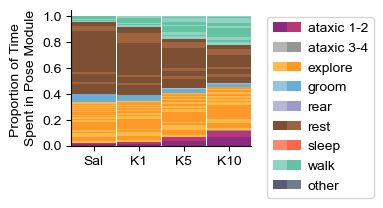

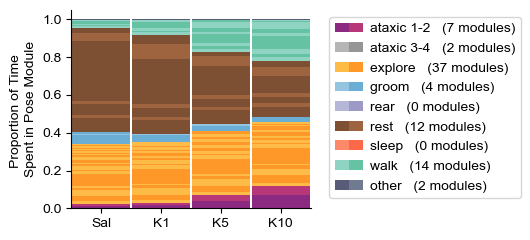

In [186]:
# labels_df = analysis.get_module_labels(config, 0, 1200, subgroups = "all")
# BORIS_to_pose_mat, BORIS_to_pose_mat_normalized, loss = analysis.BORIS_to_pose(config)
# analysis.make_remappings_from_BORIS(config,BORIS_to_pose_mat=BORIS_to_pose_mat)
# module_usage = analysis.get_module_usage(config, labels_df)
# plot.plot_module_usage(config, module_usage,figH=2,figW=4,style="stacked",legend=True,BORIS_to_pose_mat=BORIS_to_pose_mat,alt_xticks=["Sal","K1","K5","K10"])
# if save:
#     plt.savefig(save_path+"dose_pose_density_stacked.png",dpi=500)
#     
# plot.plot_module_usage(config, module_usage,figH=2.5,figW=5.5,style="stacked",legend=True,BORIS_to_pose_mat=BORIS_to_pose_mat,alt_xticks=["Sal","K1","K5","K10"],long_legend=True)
# if save:
#     plt.savefig(save_path+"dose_pose_density_stacked_LEGEND.png",dpi=500)

In [546]:
method_acc = {}
method_cmat = {}

labels_df = analysis.get_module_labels(config, 0, 1200, subgroups = "all")
module_usage = analysis.get_module_usage(config, labels_df)
module_usage = module_usage.scale()
module_transitions = analysis.get_module_transitions(config, labels_df)
module_transitions = module_transitions.scale()

for method in ["LogisticRegression","LDA","MLP","NaiveBayes","KNN","RandomForest"]:
    method_acc[method+" usage"], method_cmat[method+" usage"] = analysis.loocv(module_usage,method=method)
    clf = analysis.classify(module_usage,method=method)
    method_acc[method+" tx"], method_cmat[method+" tx"] = analysis.loocv(module_transitions,method=method)
    clf = analysis.classify(module_transitions,method=method)

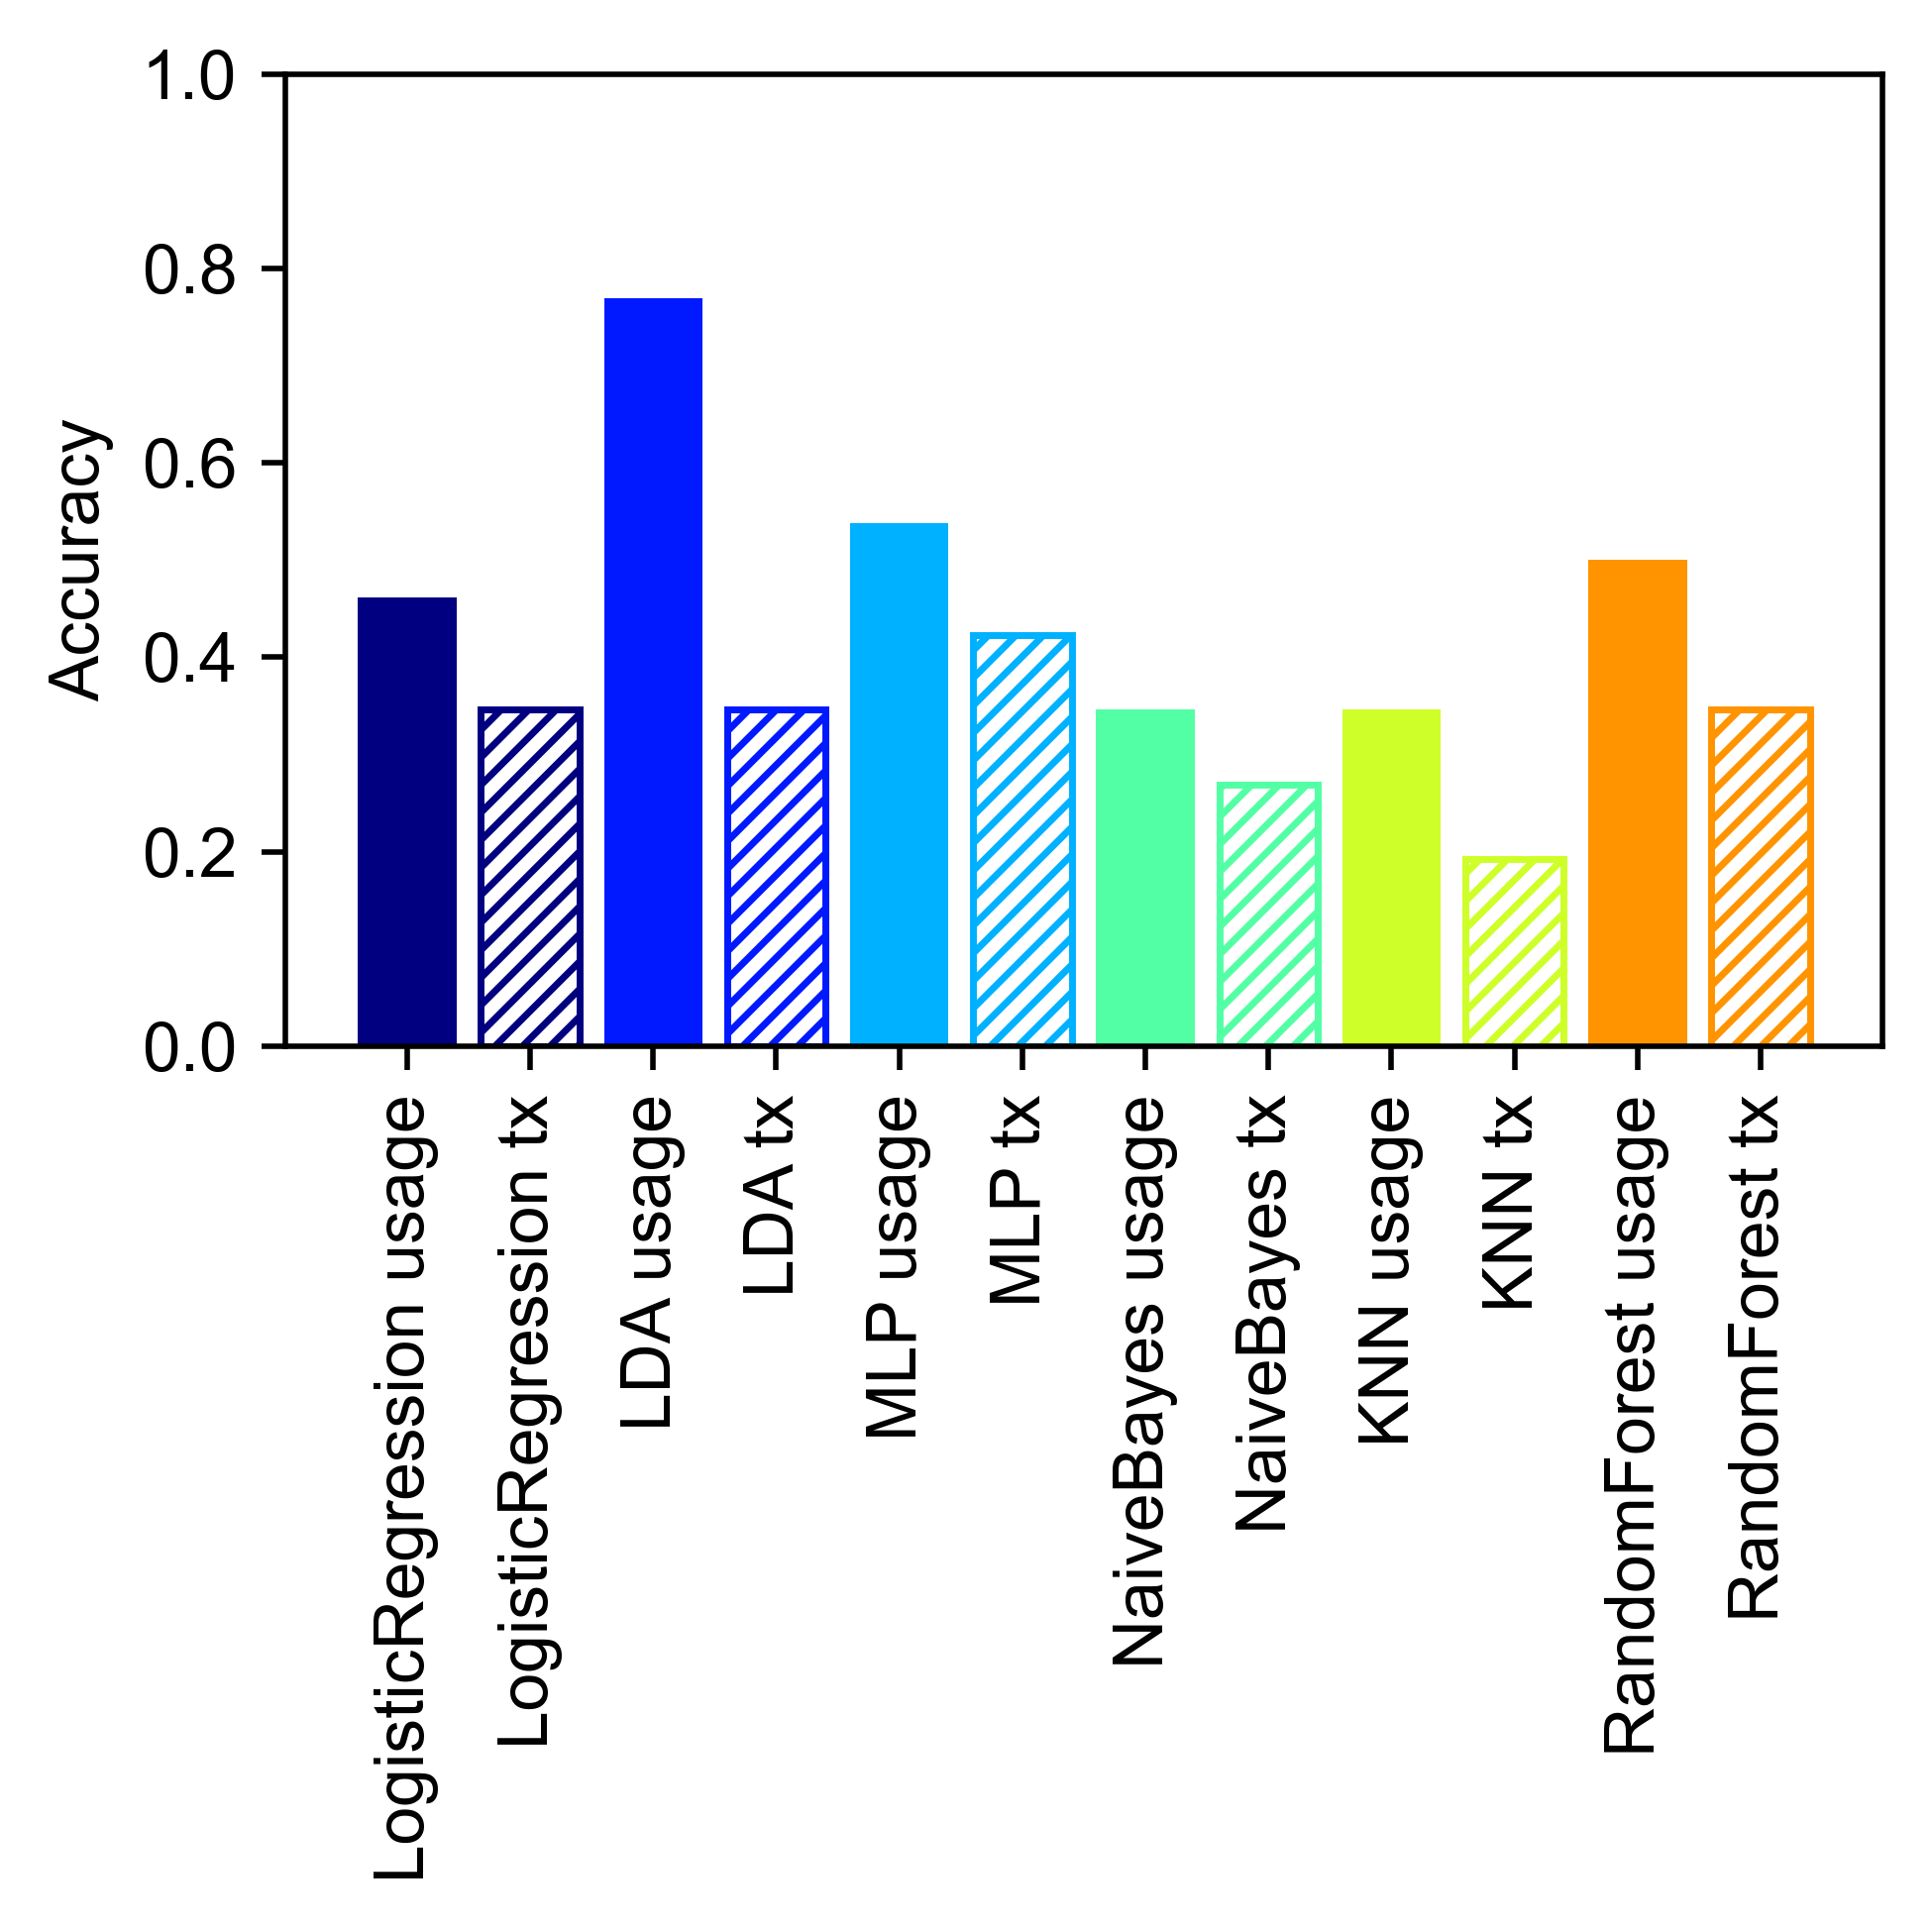

In [547]:
xticks=[]
xticklabels=[]
jet = plt.get_cmap("jet")
colors=[jet([i]) for i in np.arange(0,1,0.15)]
plt.figure(figsize=(4,4),dpi=500)
for k,key in enumerate(list(method_acc.keys())):
    if " usage" in key:
        alpha=0.5
        plt.bar(k,method_acc[key],color=colors[int(np.trunc(k/2))])
    else:
        plt.bar(k,method_acc[key],edgecolor=colors[int(np.trunc(k/2))],color="none",hatch="//////")
    xticks.append(k)
    xticklabels.append(key)
plt.xticks(xticks,labels=xticklabels,rotation=90)
plt.ylabel("Accuracy")
plt.ylim([0,1])
plt.tight_layout()
if save:
    plt.savefig(save_path+"clf.png")

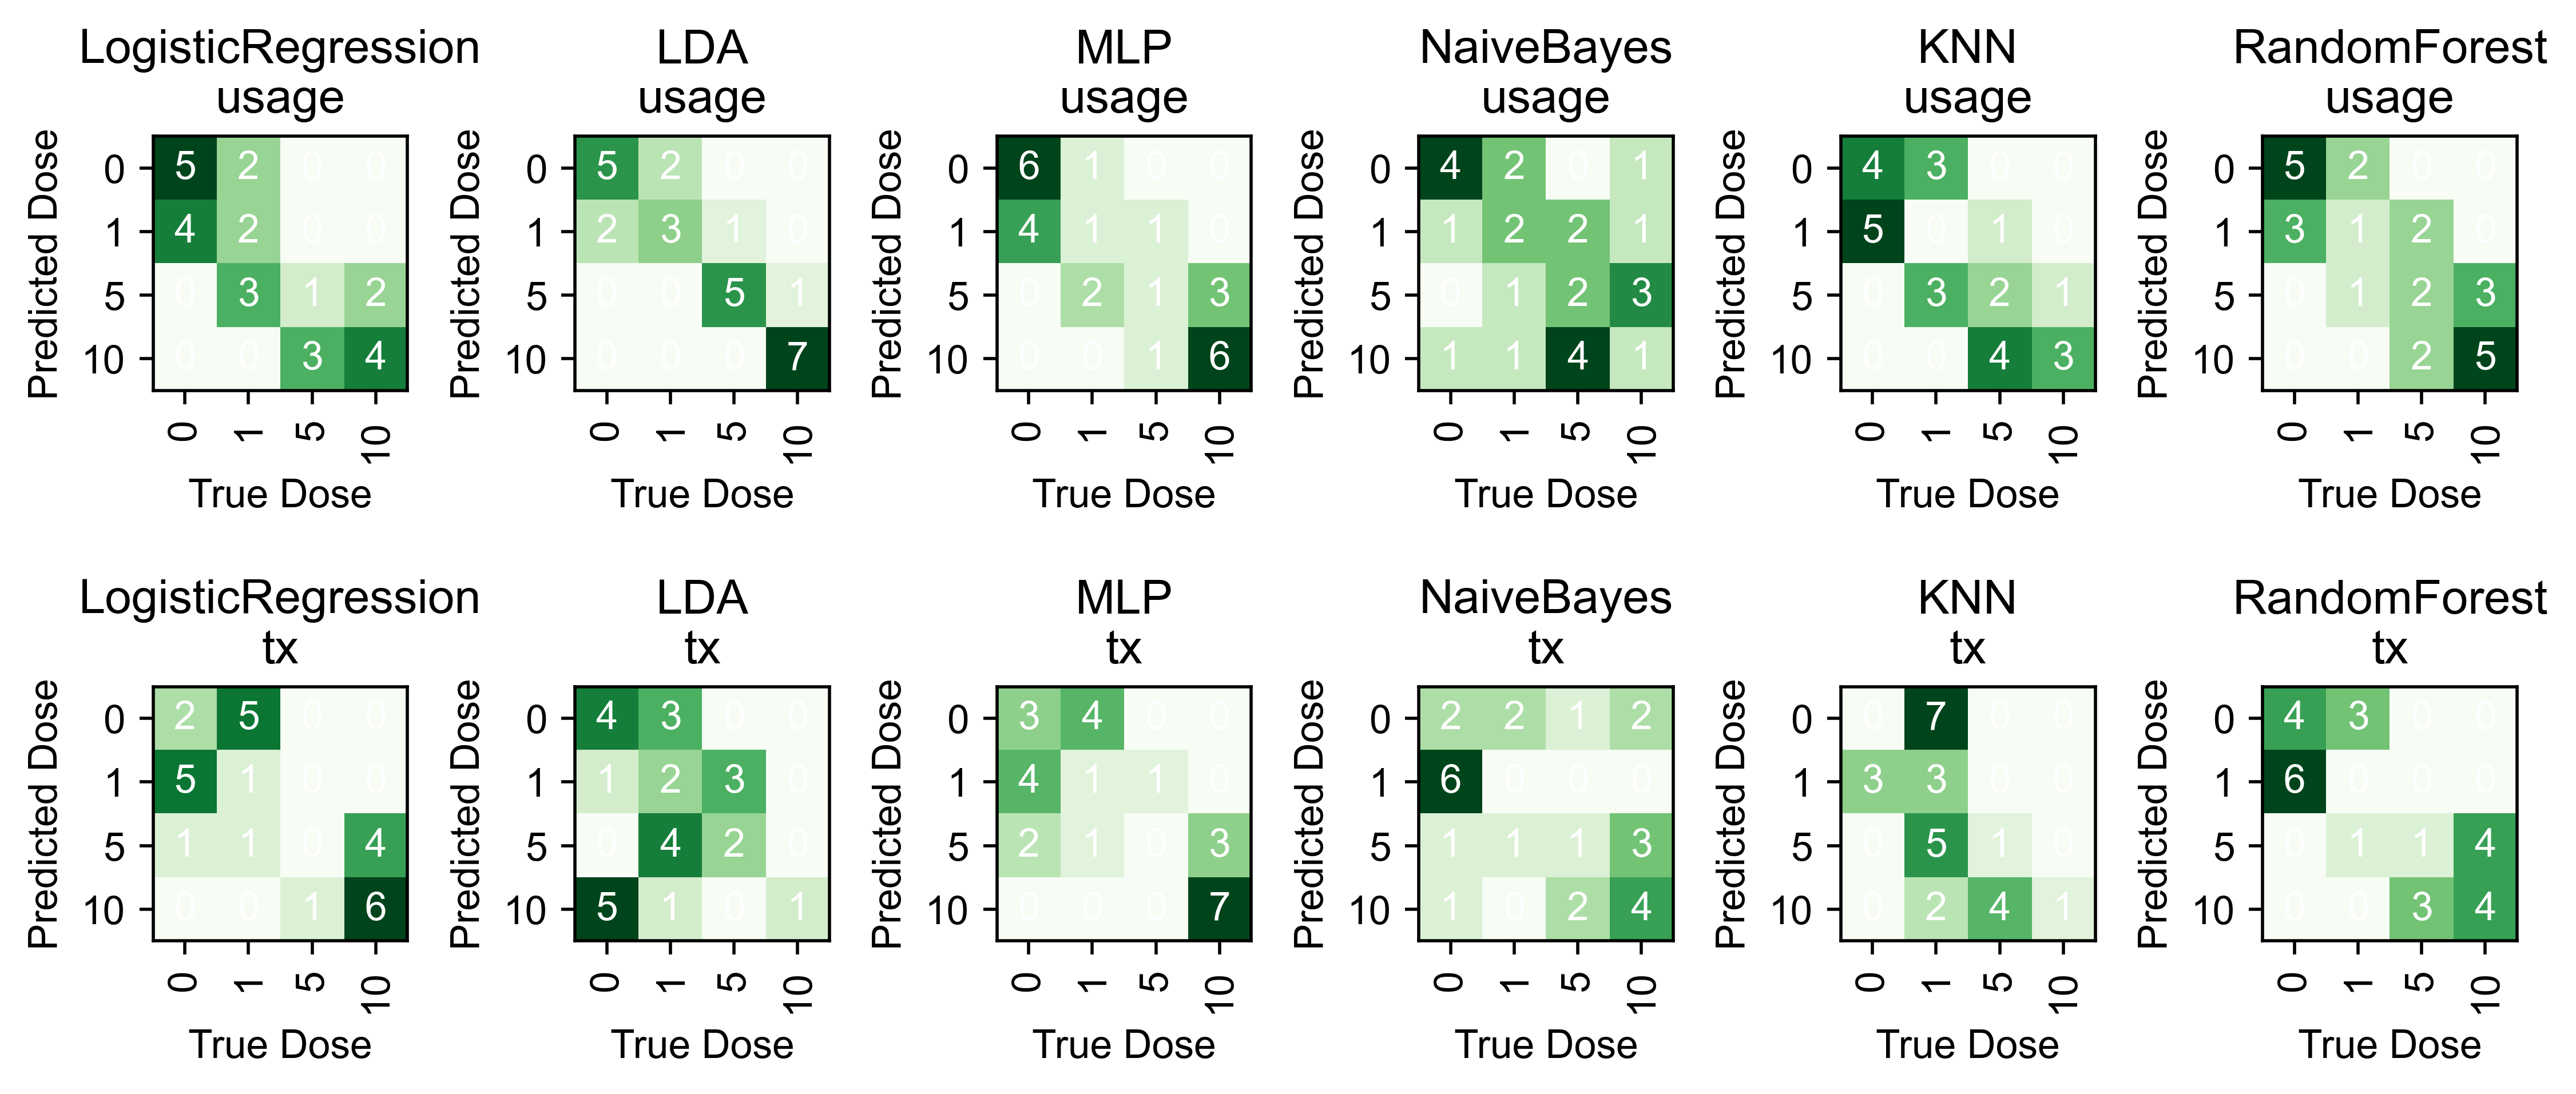

In [548]:
xticks=[]
xticklabels=[]
fig, ax = plt.subplots(2,6,figsize=(9,4),dpi=500)
for k,key in enumerate(list(method_acc.keys())):
    ax[int(k%2),int(k/2)].imshow(method_cmat[key],cmap="Greens")
    for i in range(method_cmat[key].shape[0]):
        for j in range(method_cmat[key].shape[1]):
            text = ax[int(k%2),int(k/2)].text(j, i, f"{int(method_cmat[key][i, j])}",
                           ha="center", va="center", color="white")
    ax[int(k%2),int(k/2)].set_xticks([i[1] for i in list(module_usage.group_dict.items())],
                                     [0,1,5,10],rotation=90)
    ax[int(k%2),int(k/2)].set_yticks([i[1] for i in list(module_usage.group_dict.items())],
                                     [0,1,5,10])
    ax[int(k%2),int(k/2)].set_title("\n".join(key.split(" ")))
    ax[int(k%2),int(k/2)].set_xlabel("True Dose")
    ax[int(k%2),int(k/2)].set_ylabel("Predicted Dose")
plt.tight_layout()
if save:
    plt.savefig(save_path+"confmat.png")

In [549]:
module_usage = analysis.get_module_usage(config, labels_df)
module_transitions = analysis.get_module_transitions(config, labels_df)

Labels LinearRegression, alpha 1 RMSE: 1.88
Labels Lasso, alpha 1 RMSE: 2.40
Labels Lasso, alpha 0.5 RMSE: 1.84
Labels Lasso, alpha 0.1 RMSE: 1.55
Labels Ridge, alpha 1 RMSE: 1.83
Labels Ridge, alpha 0.5 RMSE: 1.85
Labels Ridge, alpha 0.1 RMSE: 1.87
Transitions LinearRegression, alpha 1 RMSE: 2.00
Transitions Lasso, alpha 1 RMSE: 3.02
Transitions Lasso, alpha 0.5 RMSE: 2.92


/opt/anaconda3/envs/mariposa/lib/python3.8/site-packages/sklearn/linear_model/_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.162e-02, tolerance: 3.874e-02
  model = cd_fast.enet_coordinate_descent(


Transitions Lasso, alpha 0.1 RMSE: 2.70
Transitions Ridge, alpha 1 RMSE: 2.01
Transitions Ridge, alpha 0.5 RMSE: 2.01
Transitions Ridge, alpha 0.1 RMSE: 2.01


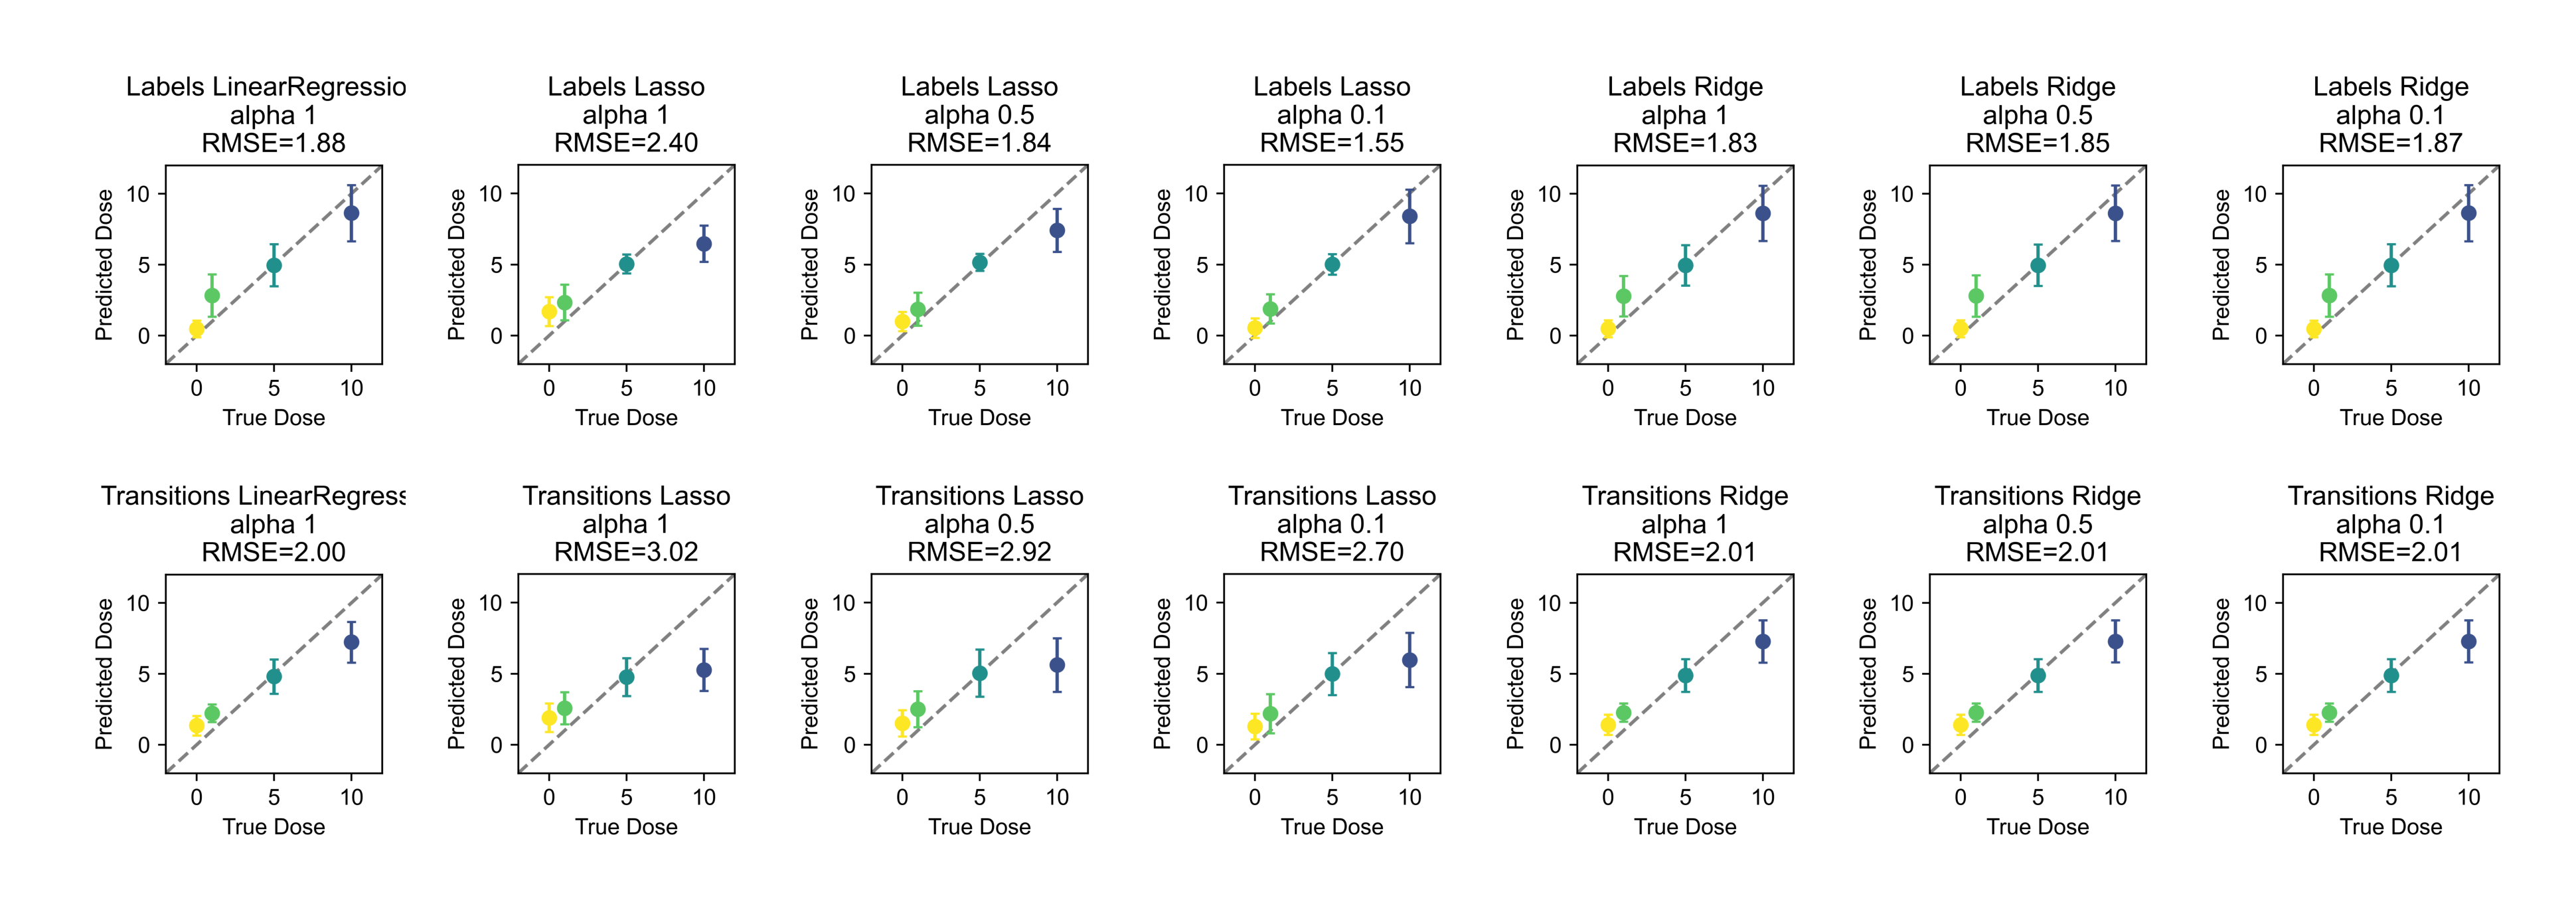

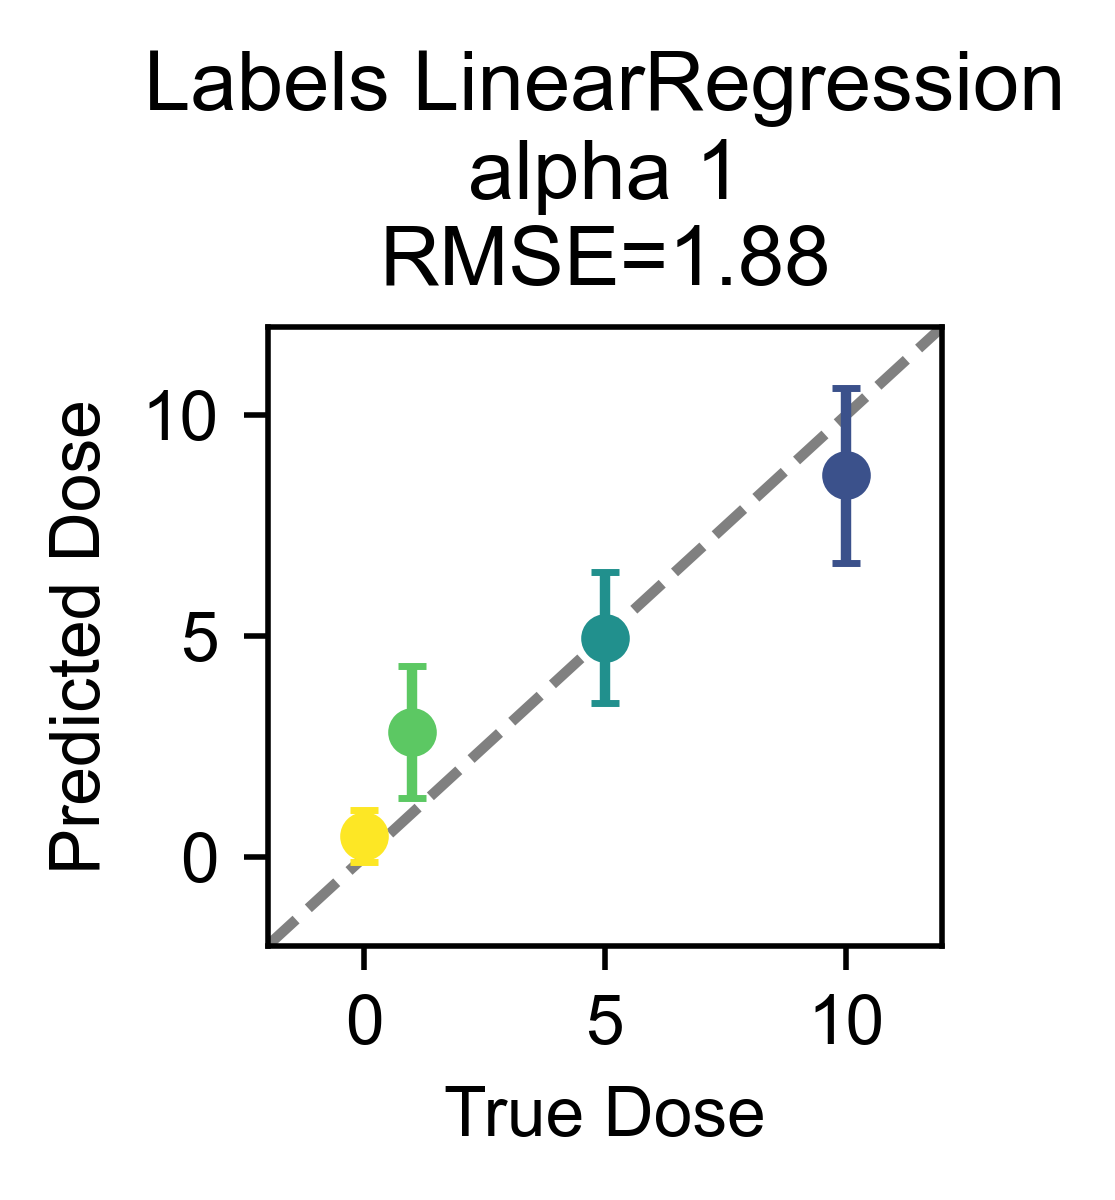

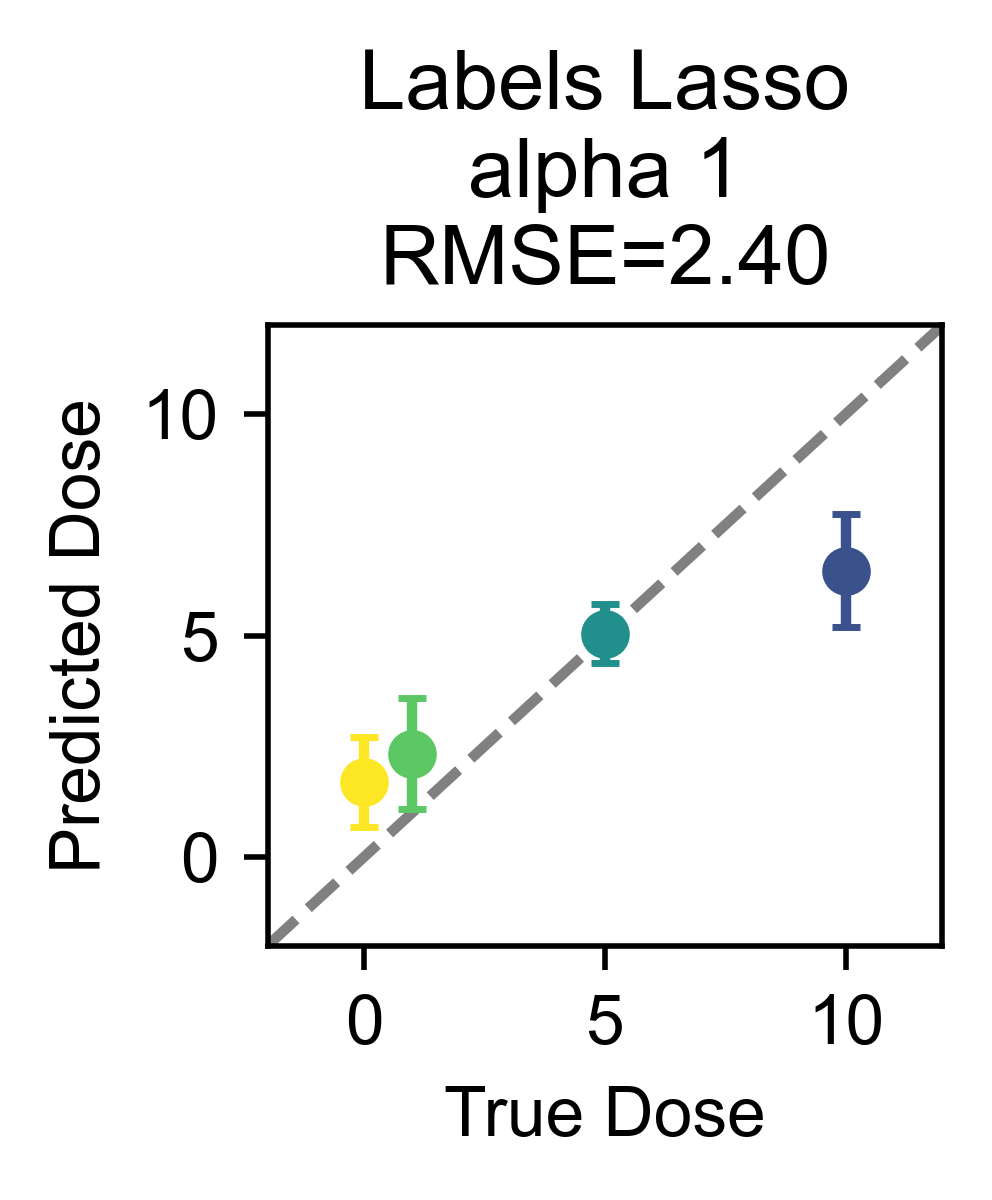

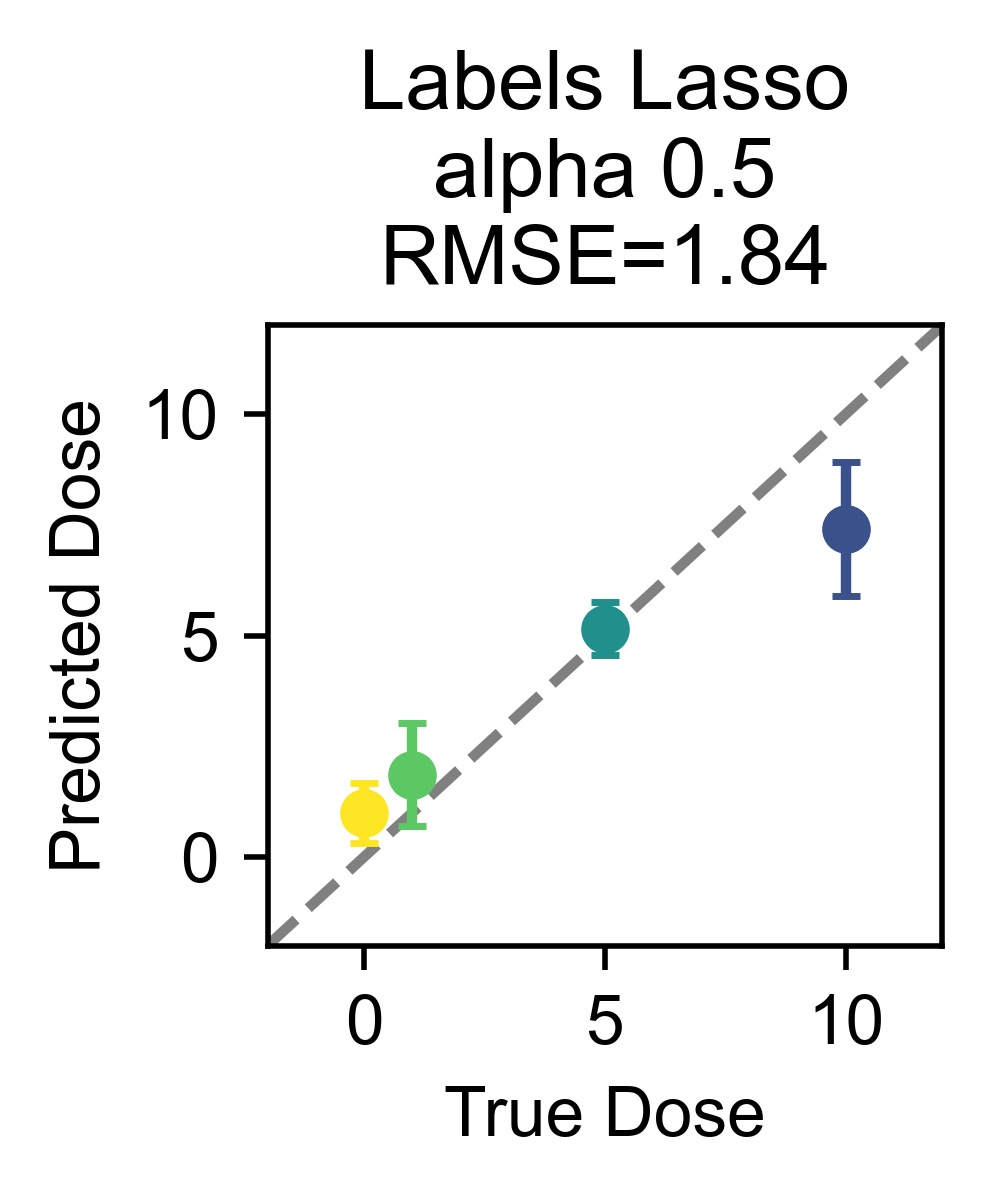

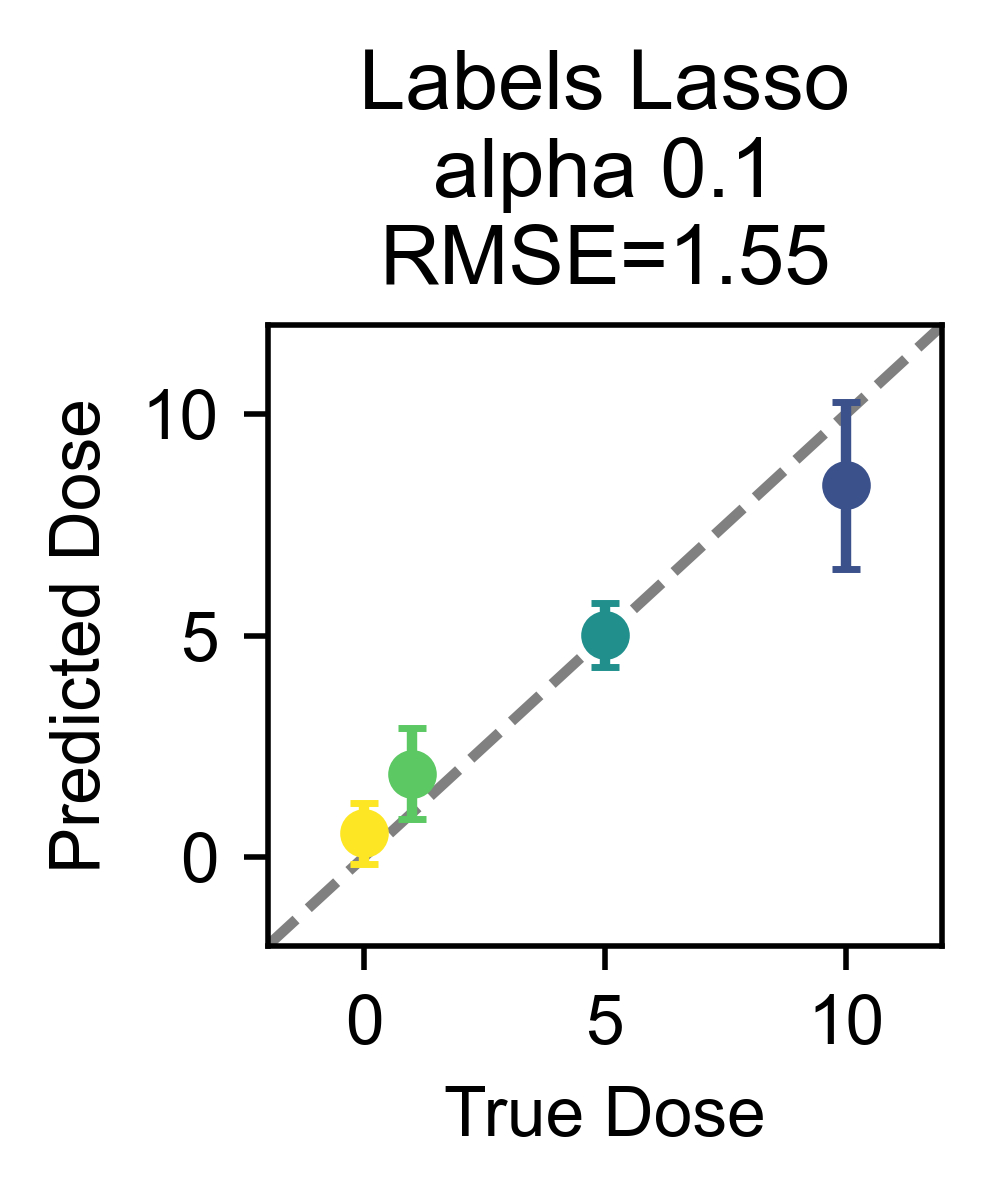

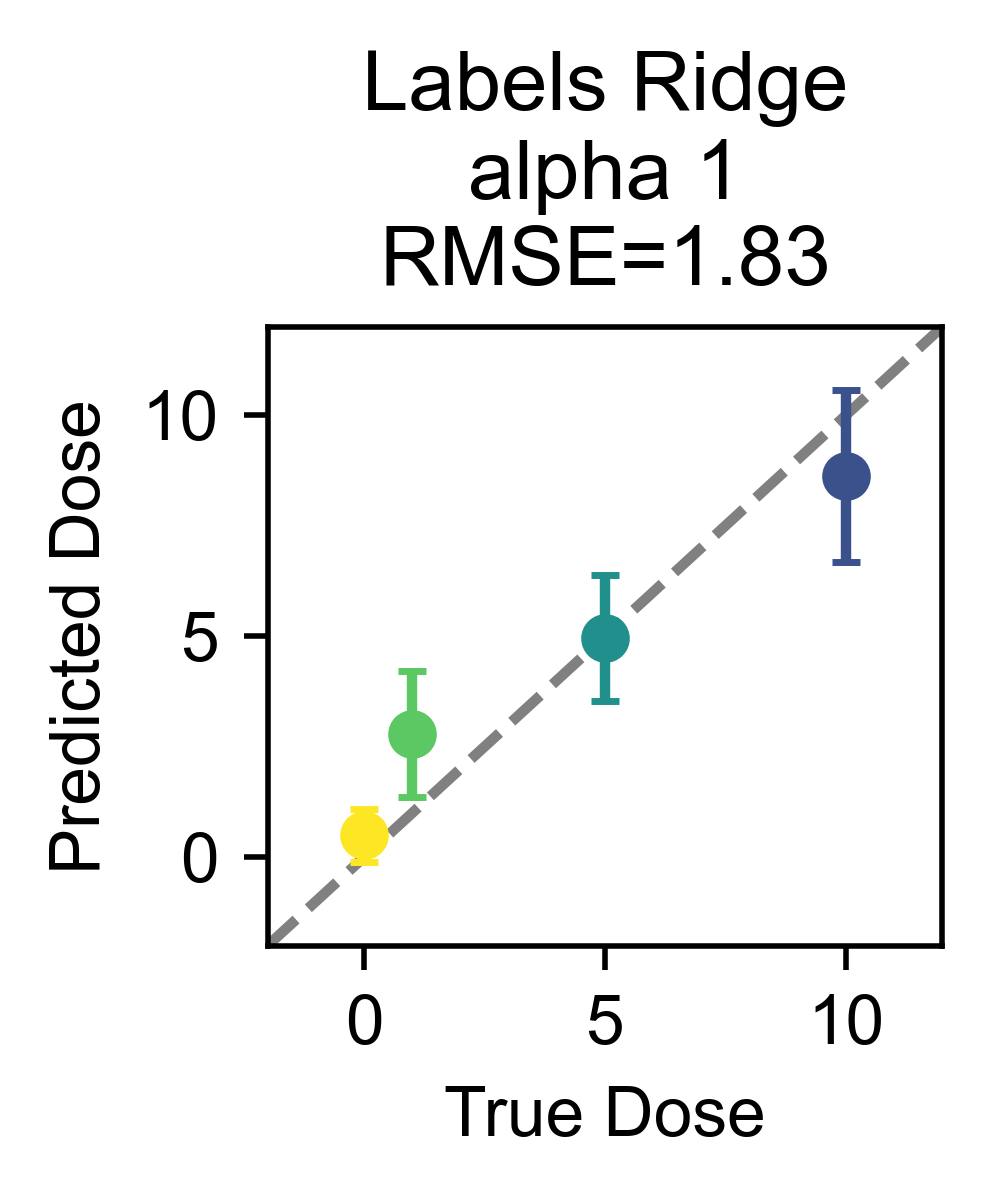

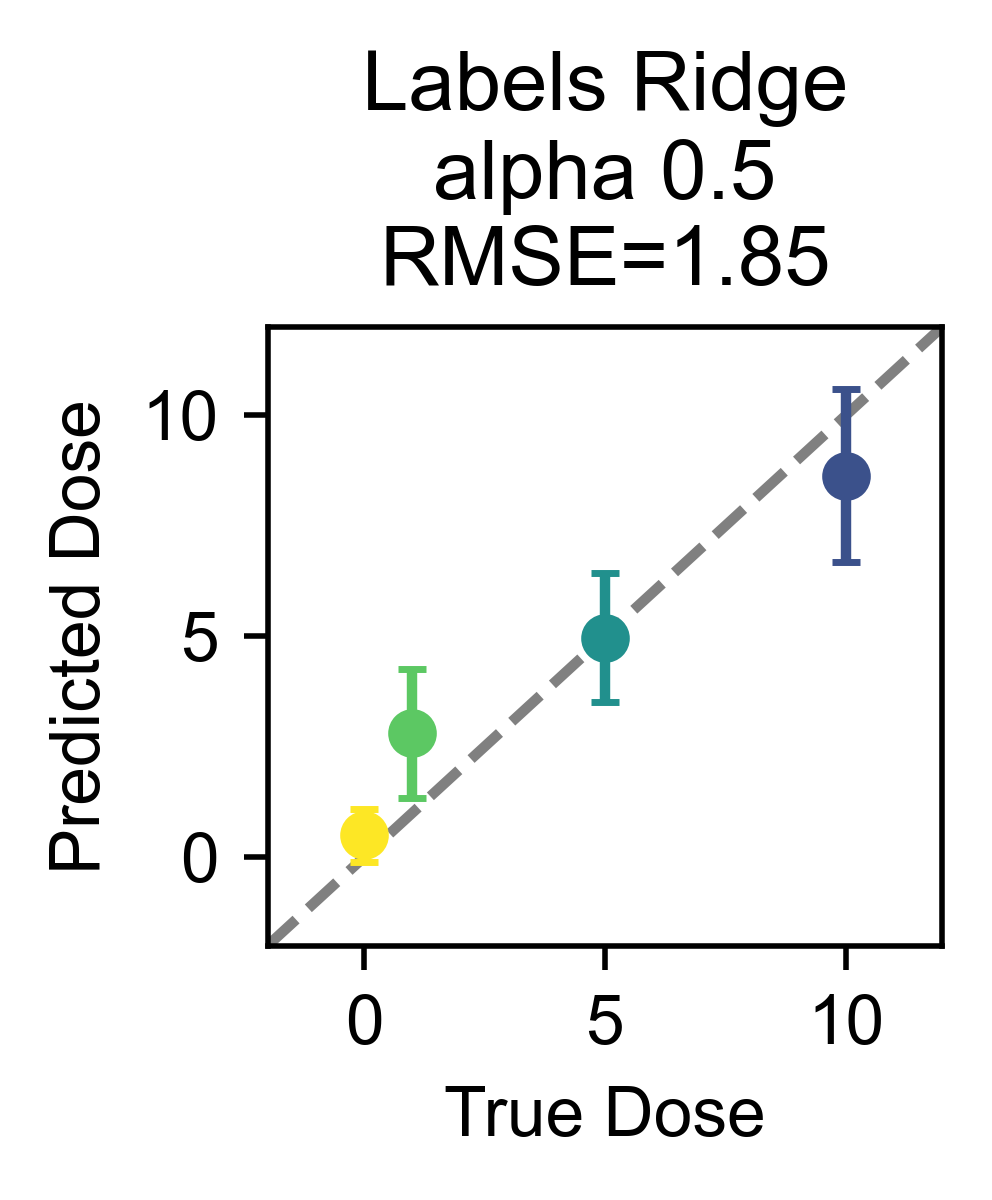

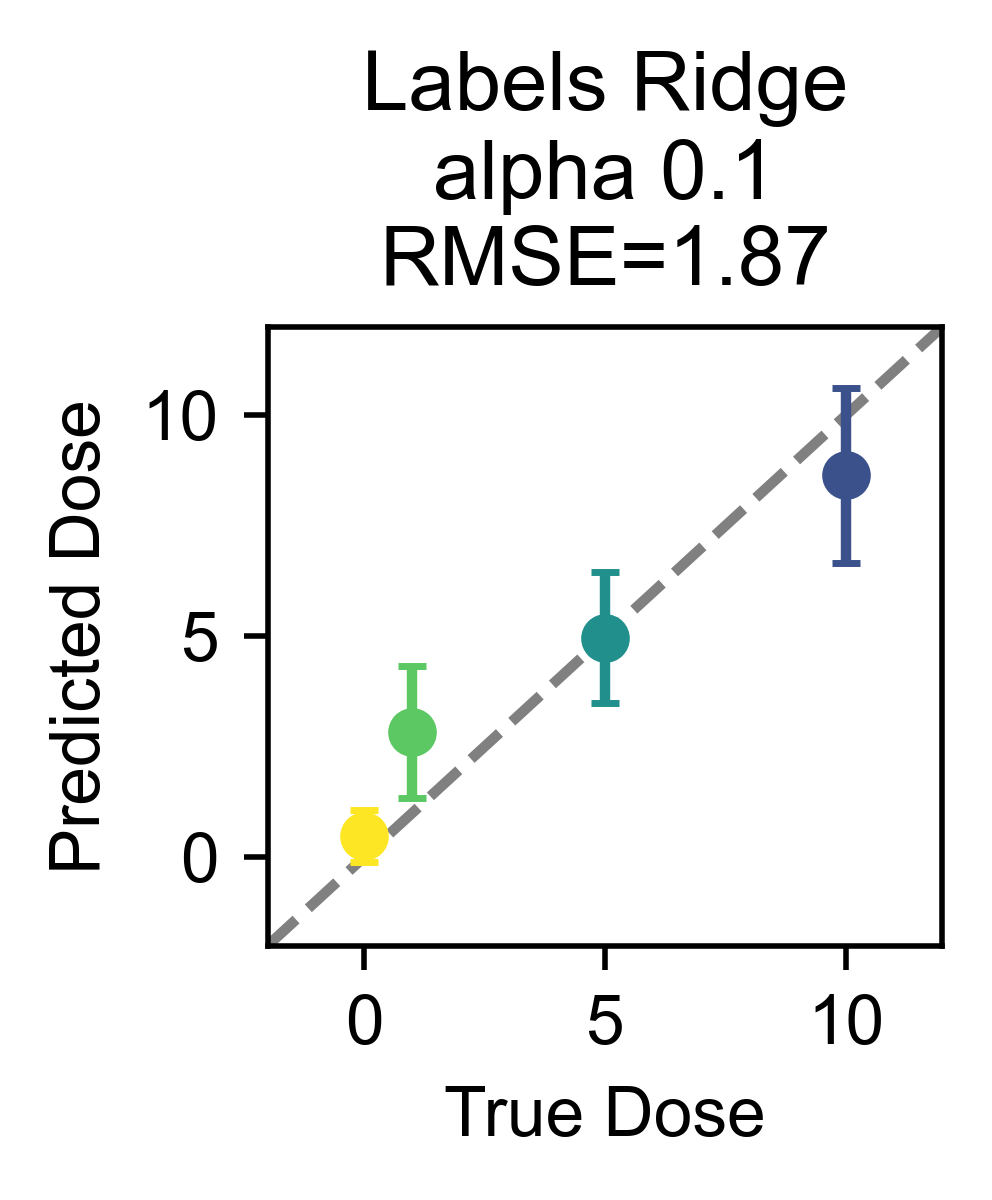

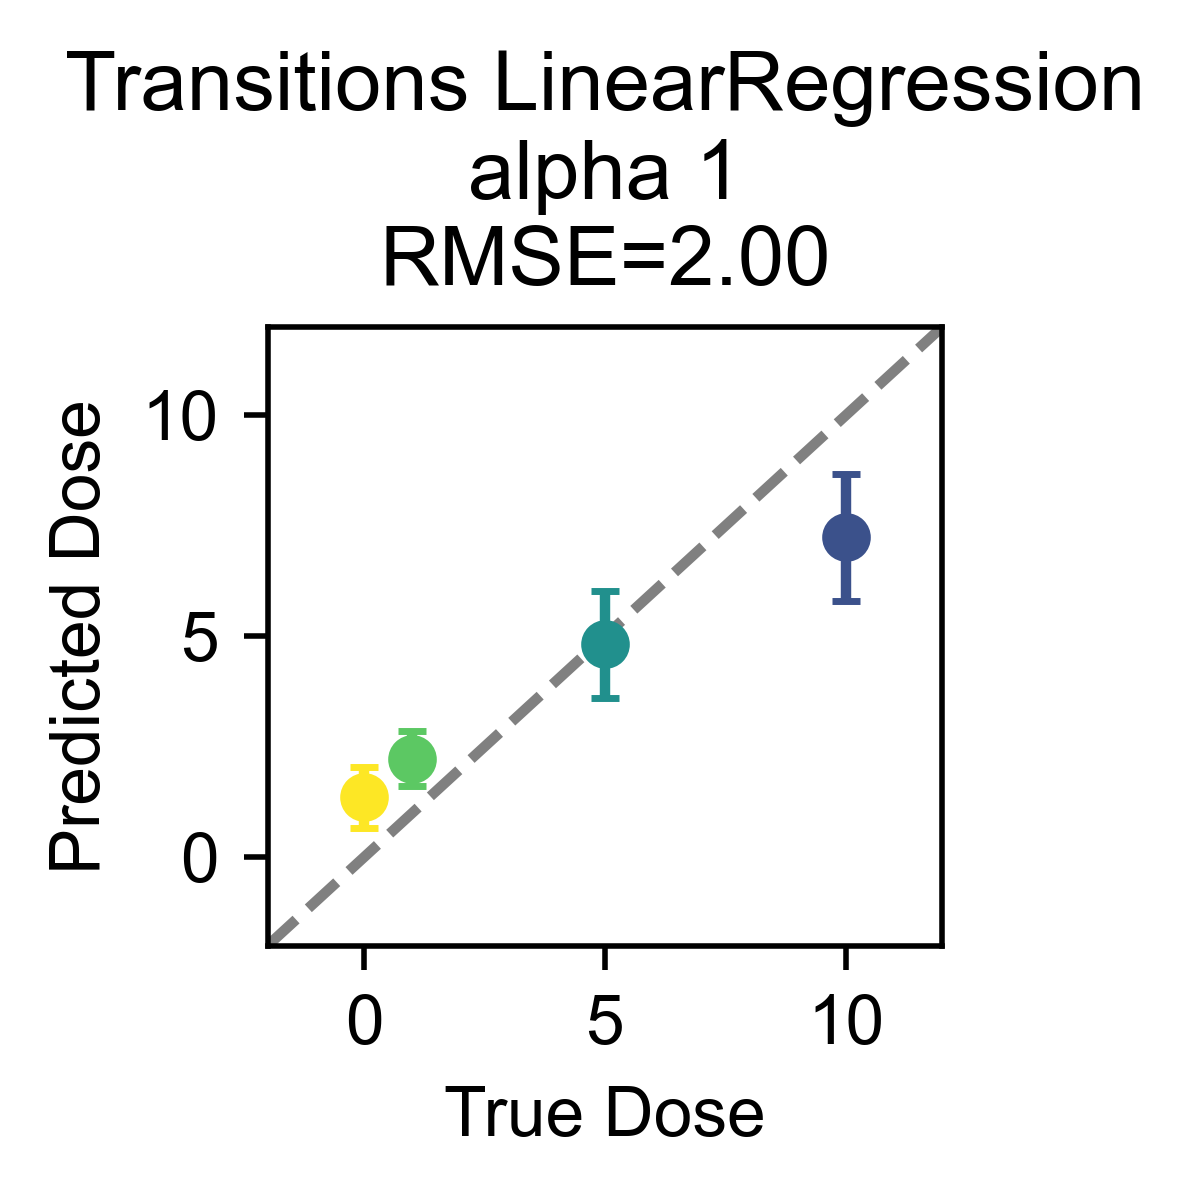

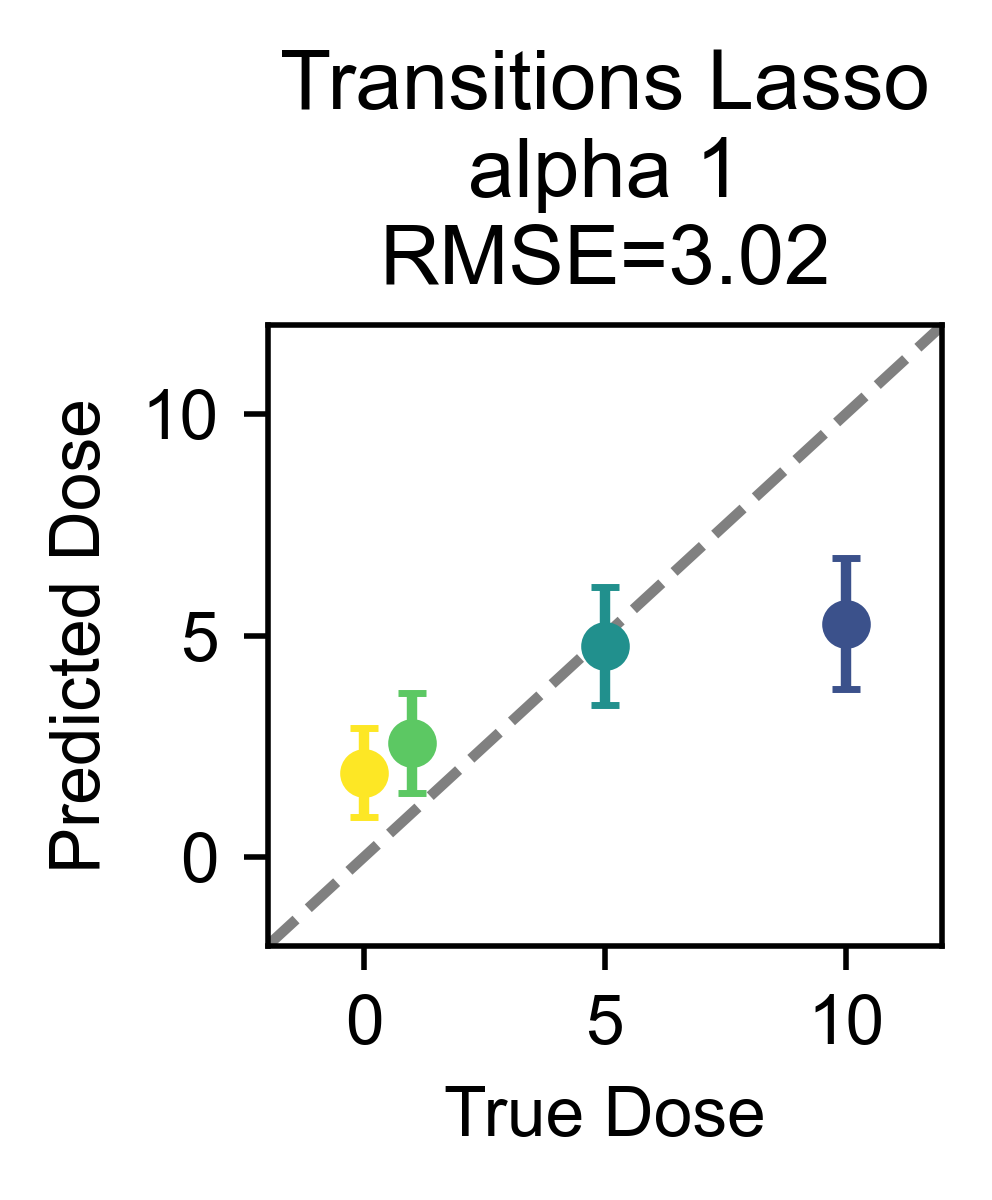

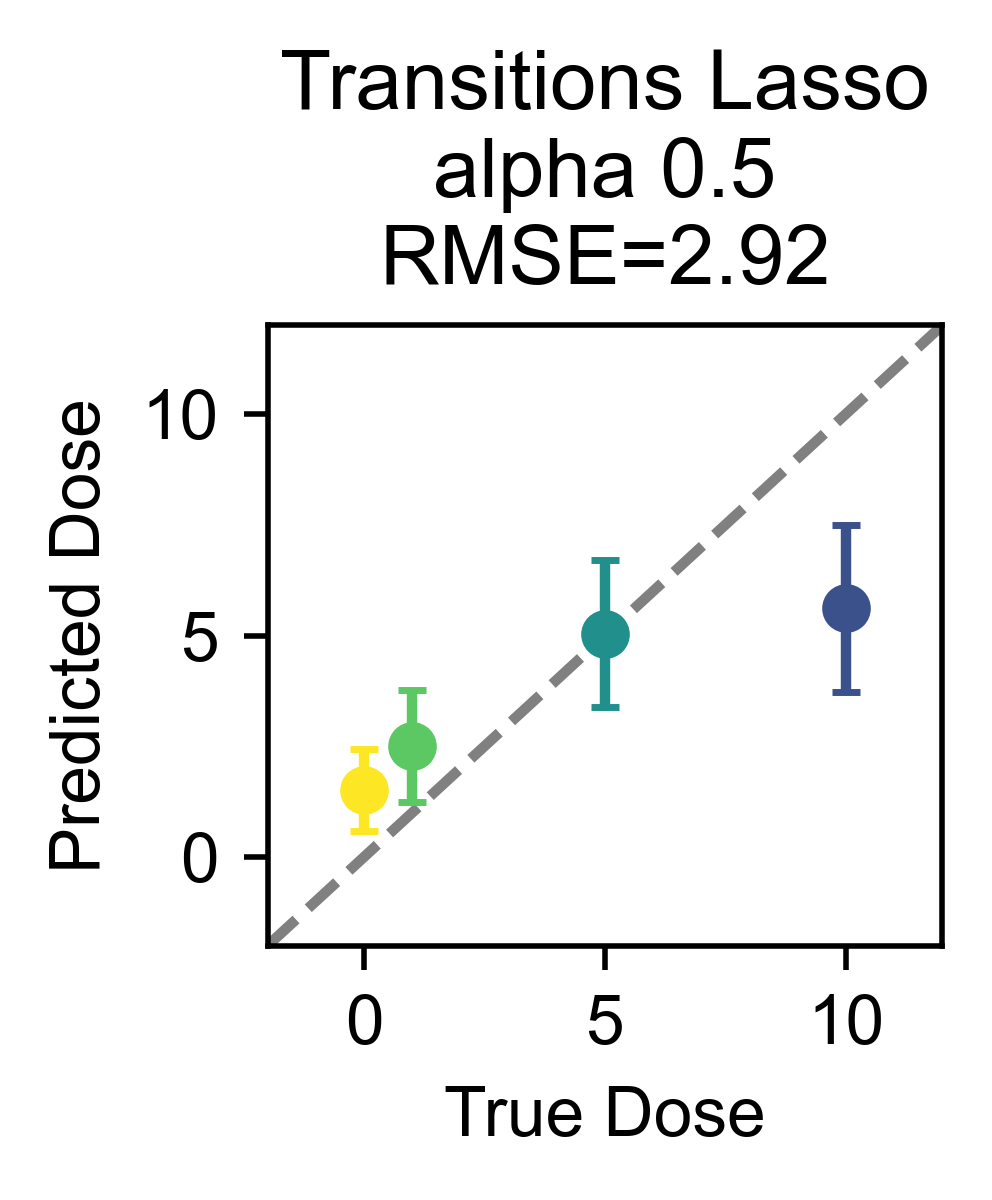

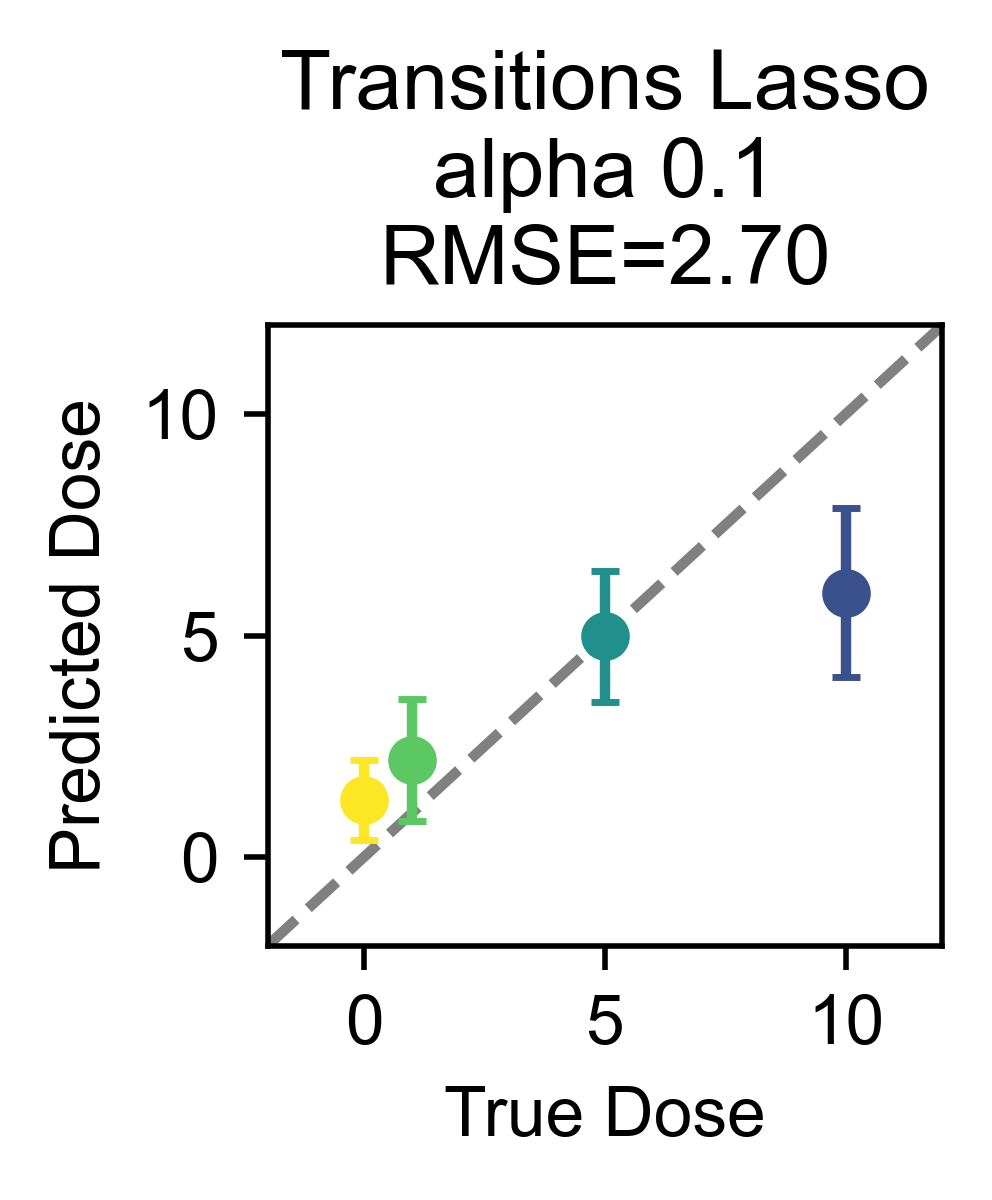

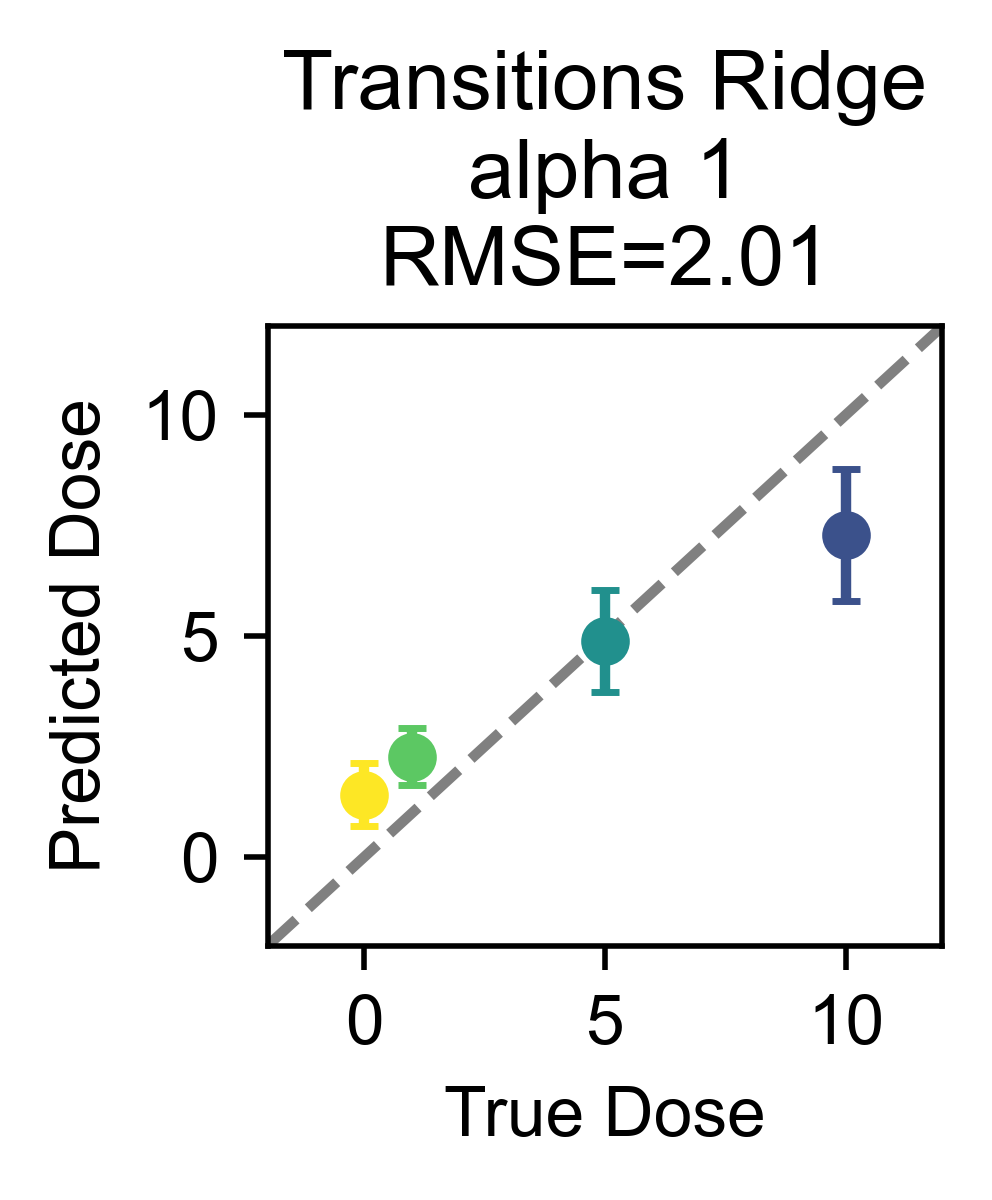

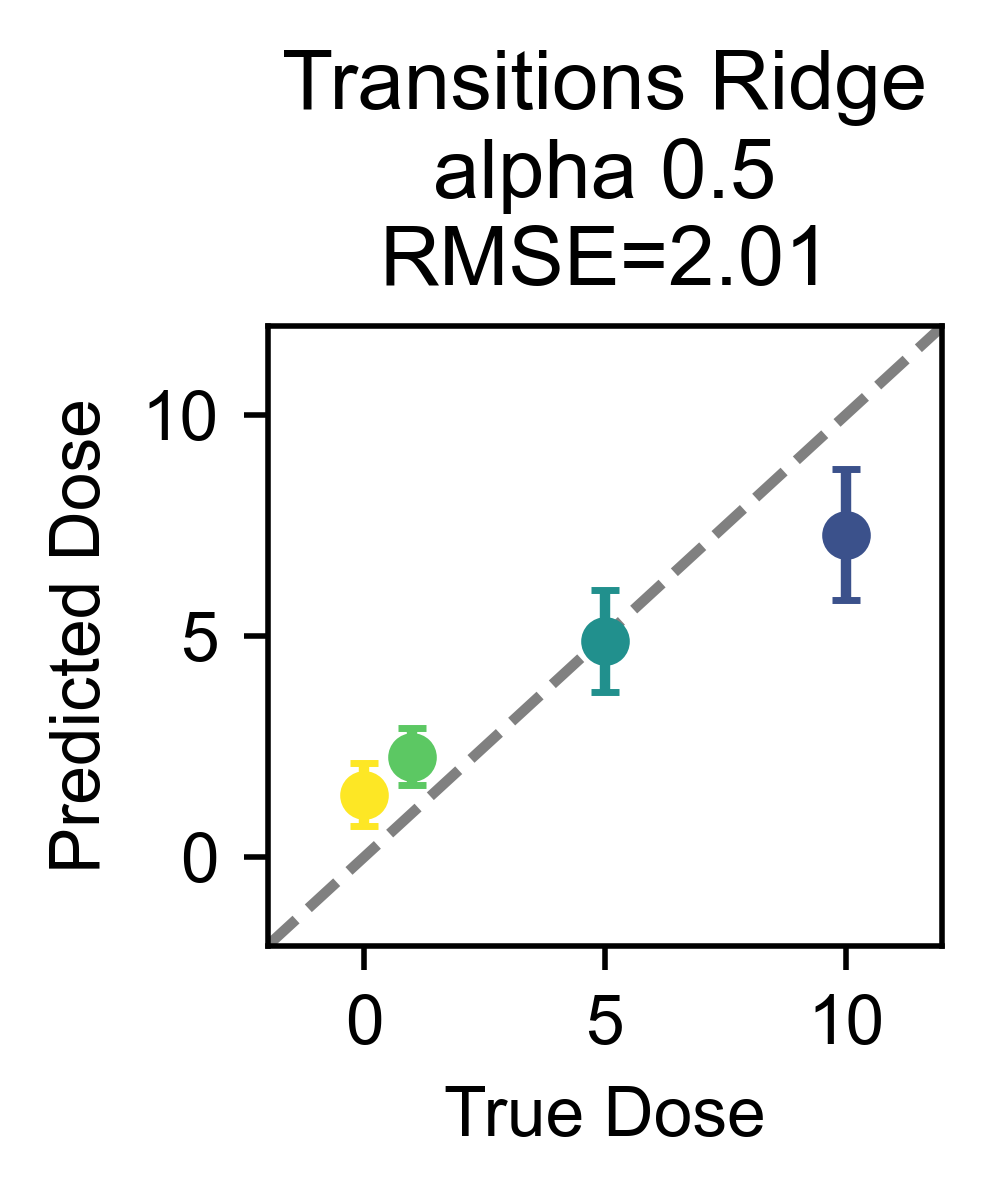

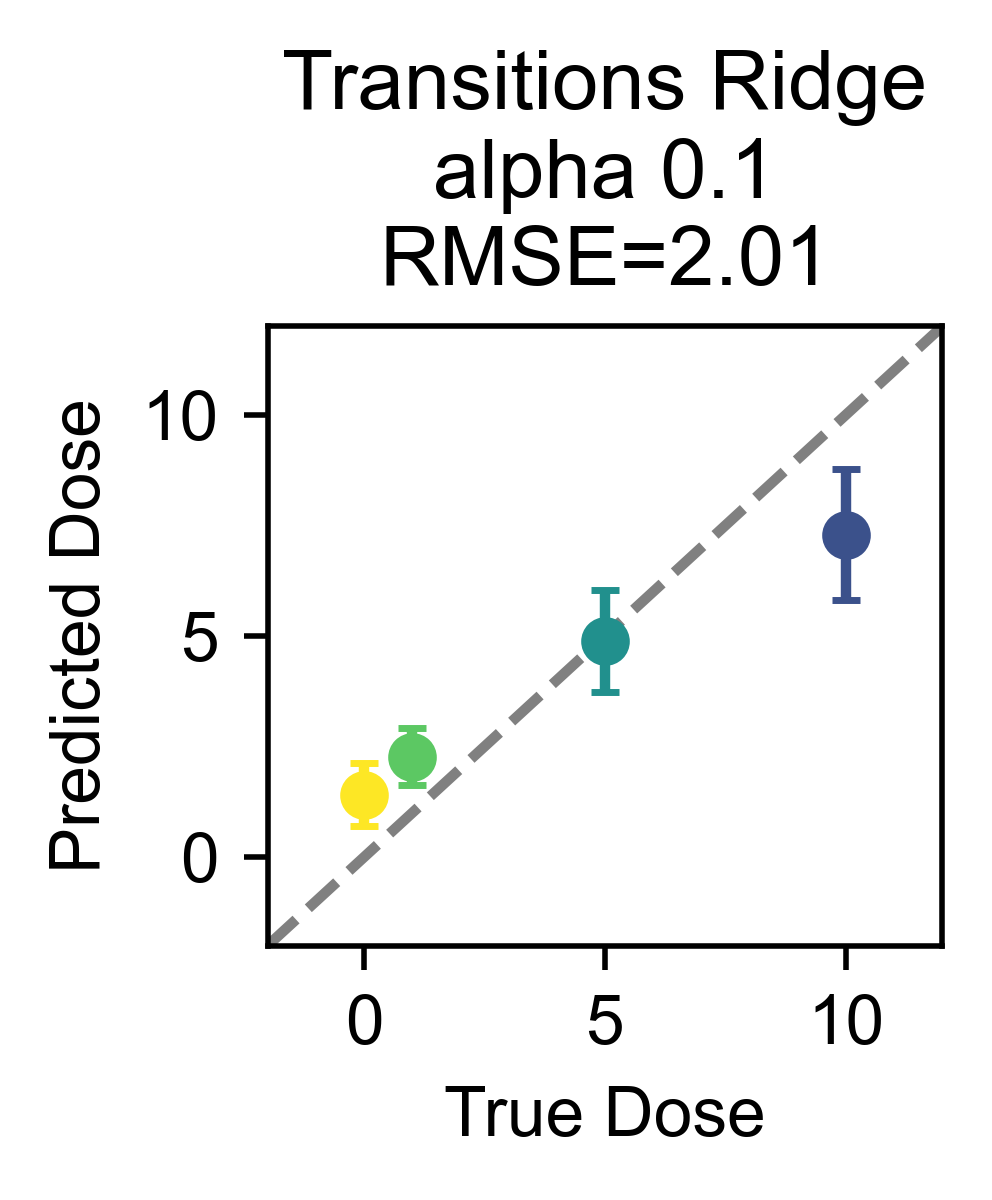

In [550]:
module_usage.label_counts
dose_dict={'saliv': 0, 'k1iv': 1, 'k5iv': 5, 'k10iv': 10}

module_usage_scaled = module_usage.scale()
module_transitions_scaled = module_transitions.scale()

cmap=jet = plt.get_cmap("viridis_r")

ims=[]
fig_main, main_axes = plt.subplots(2,7, figsize=(6,2),dpi=800)
plt.subplots_adjust(wspace=0, hspace=0)

for m,method in enumerate([["LinearRegression",1],["Lasso",1],["Lasso",0.5],["Lasso",0.1],["Ridge",1],["Ridge",0.5],["Ridge",0.1]]):
    fig = plt.figure(figsize=(2.2,2.5),dpi=500)
    plt.xlabel("True Dose")
    plt.ylabel("Predicted Dose")
    plt.ylim([-2,12])
    plt.xlim([-2,12])
    plt.axline([0,0],[1,1],linestyle="dashed",color="gray")
    reg, dose_labels = analysis.regress(module_usage_scaled,dose_dict,method=method[0],alpha=method[1])
    y_hat = reg.predict(module_usage_scaled.label_counts)
    loocv_preds, sq_err = analysis.loocv_regression(module_usage_scaled,dose_dict,method=method[0],alpha=method[1])
    dose_cats = np.unique(dose_labels)
    colors = [cmap([i]) for i in np.arange(0,1,1/len(dose_cats))]
    for d, do in enumerate(dose_cats):
        y_d_hat = loocv_preds[dose_labels==do]
        plt.errorbar(do,np.mean(y_d_hat),yerr=np.std(y_d_hat),marker="o",capsize=2,color=colors[d])
    rmse=np.sqrt(np.mean(sq_err))
    plt.title(f'Labels {method[0]}\nalpha {method[1]}\nRMSE={rmse:.2f}')
    print(f'Labels {method[0]}, alpha {method[1]} RMSE: {rmse:.2f}')
    plt.tight_layout()
    im = plot.fig_to_array(fig)
    main_axes[0,m].imshow(im)
    main_axes[0,m].axis('off')
    main_axes[0,m].set_xticklabels([])
    main_axes[0,m].set_yticklabels([])


for m,method in enumerate([["LinearRegression",1],["Lasso",1],["Lasso",0.5],["Lasso",0.1],["Ridge",1],["Ridge",0.5],["Ridge",0.1]]):
    fig = plt.figure(figsize=(2.2,2.5),dpi=500)
    plt.xlabel("True Dose")
    plt.ylabel("Predicted Dose")
    plt.ylim([-2,12])
    plt.xlim([-2,12])
    plt.axline([0,0],[1,1],linestyle="dashed",color="gray")
    reg, dose_labels = analysis.regress(module_transitions_scaled,dose_dict,method = method[0],alpha=method[1])
    y_hat = reg.predict(module_transitions_scaled.transition_counts)
    loocv_preds, sq_err = analysis.loocv_regression(module_transitions_scaled,dose_dict,method = method[0],alpha=method[1])
    dose_cats = np.unique(dose_labels)
    colors = [cmap([i]) for i in np.arange(0,1,1/len(dose_cats))]
    for d, do in enumerate(dose_cats):
        y_d_hat = loocv_preds[dose_labels==do]
        plt.errorbar(do,np.mean(y_d_hat),yerr=np.std(y_d_hat),marker="o",capsize=2,color=colors[d])
    rmse=np.sqrt(np.mean(sq_err))
    plt.title(f'Transitions {method[0]}\nalpha {method[1]}\nRMSE={rmse:.2f}')
    print(f'Transitions {method[0]}, alpha {method[1]} RMSE: {rmse:.2f}')
    plt.tight_layout()
    im = plot.fig_to_array(fig)
    main_axes[1,m].imshow(im)
    main_axes[1,m].axis('off')
    main_axes[1,m].set_xticklabels([])
    main_axes[1,m].set_yticklabels([])

if save:
    fig_main.savefig(save_path+"regr.png",dpi=800)

In [551]:
# group="k10iv"
# labels_df = analysis.get_module_labels(config,0,60*50,subgroups=[group])
# fig = plot.SandPlotClusterFrequency_OverTime(config, labels_df[group],0, 30, 100)

In [552]:
# modules = sorted(np.unique([int(i.split("module")[1].split("_")[0]) for i in list(df.columns) if "module" in i]))
# start_times = [int(col.split("_t")[1].split("-")[0]) for col in list(df.columns) if f"module{modules[0]}_" in col]
# subjs = list(df.index)
# data = []
# for subj in subjs:
#     new_df = pd.DataFrame(columns=start_times,index=modules)
#     for module in modules:
#         new_df.loc[module] = np.array(df.filter(like=f"module{module}_", axis=1).loc[subj])
#     data.append(new_df)

done with ['BINARY_2023-05-09_17-41-11_bf01_nal10k10.csv', '2023-05-09_17-41-11_bf01_nal10k10DLC_resnet101_all_pose_vidsJul17shuffle1_500000.csv']
done with ['BINARY_13-39-15_bm01_k25.csv', '2023-05-30_13-39-15_bm01_k25DLC_resnet101_all_pose_vidsJul17shuffle1_500000.csv']
done with ['BINARY_2024-05-09_13-38-52_bf33_d15.csv', '2024-05-09_13-38-52_bf33_d15DLC_resnet101_all_pose_vidsJul17shuffle1_500000.csv']
done with ['BINARY_1_2023-05-31_12-02-23_bf02_coc.csv', '2023-05-31_12-02-23_bf02_cocDLC_resnet101_all_pose_vidsJul17shuffle1_500000.csv']
done with ['BINARY_2023-06-15_19-15-24_bm04_nalket.csv', '2023-06-15_19-15-24_bm04_nalketDLC_resnet101_all_pose_vidsJul17shuffle1_500000.csv']
done with ['BINARY_2023-06-15_17-16-18_bm01_k5iv.csv', '2023-06-15_17-16-18_bm01_k5ivDLC_resnet101_all_pose_vidsJul17shuffle1_500000.csv']
done with ['BINARY_2023-06-09_18-18-49_bm02_k25.csv', '2023-06-09_18-18-49_bm02_k25DLC_resnet101_all_pose_vidsJul17shuffle1_500000.csv']
done with ['BINARY_2023-07-08_15

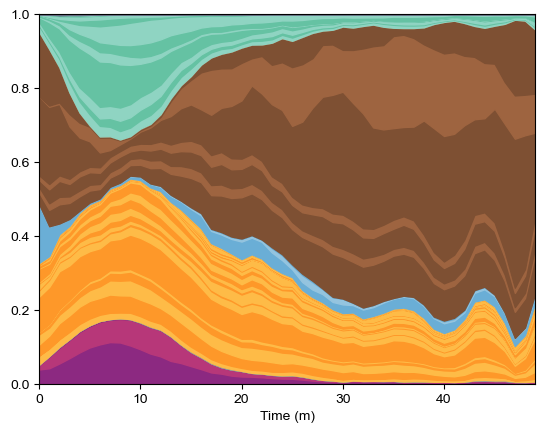

In [553]:
group="k10iv"
labels_df = analysis.get_module_labels(config,0,60*50,subgroups=[group])
module_usage = analysis.get_module_usage(config, labels_df,binsize=60)
BORIS_to_pose_mat, BORIS_to_pose_mat_normalized, loss = analysis.BORIS_to_pose(config)
analysis.make_remappings_from_BORIS(config,BORIS_to_pose_mat=BORIS_to_pose_mat)

plot.module_usage_sandplot(config, module_usage, BORIS_to_pose_mat = BORIS_to_pose_mat_normalized, convolve=True, long_legend=True)

Labels LinearRegression, alpha 0.1 RMSE: 1.61


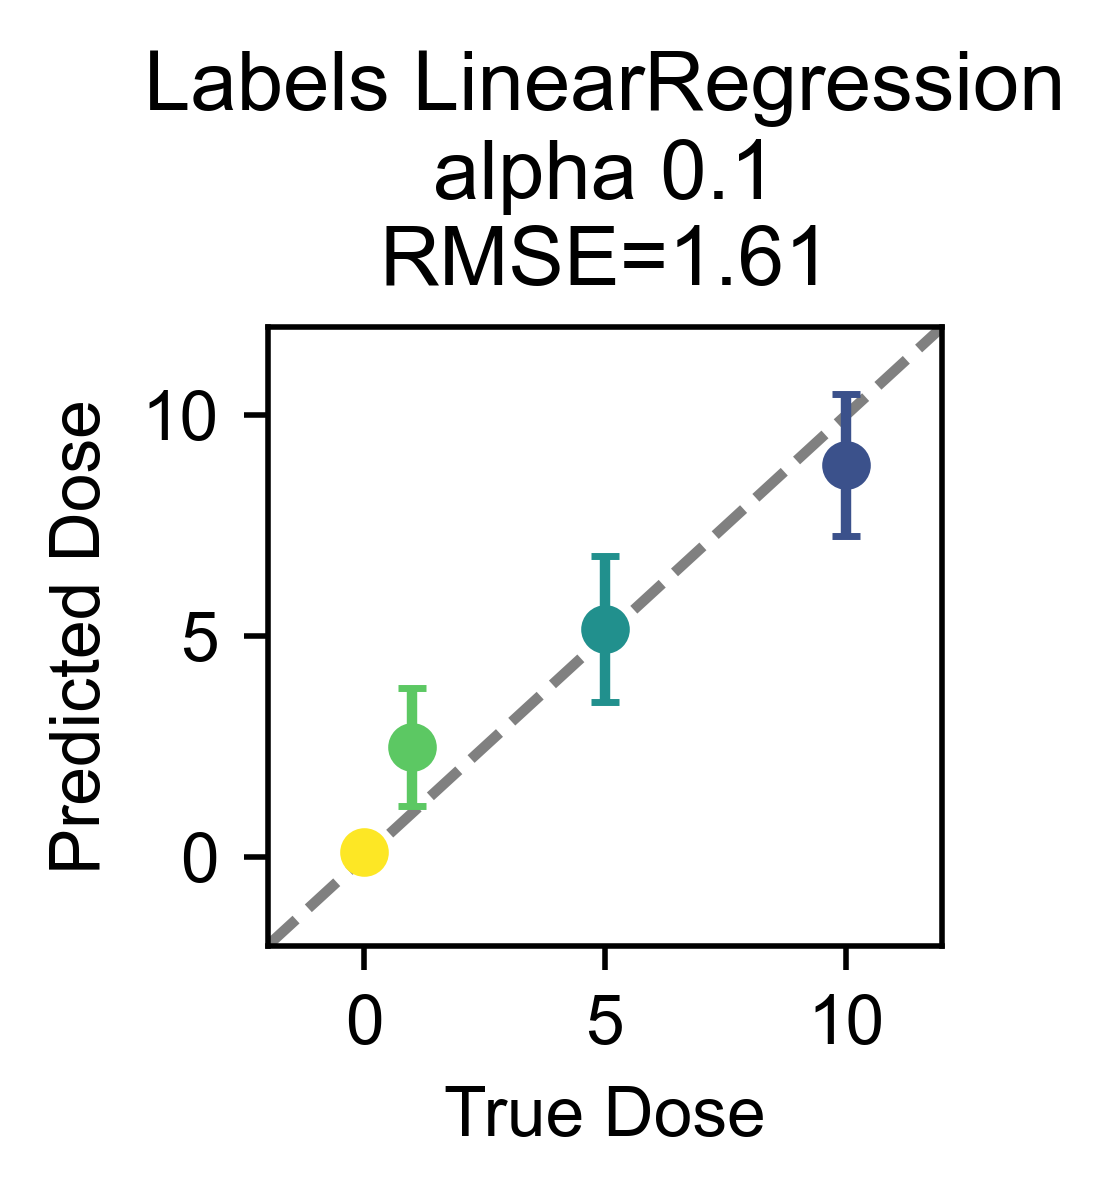

In [554]:
labels_df = analysis.get_module_labels(config,0,1200,subgroups="all")
all_module_usage = analysis.get_module_usage(config, labels_df)

cmap = plt.get_cmap("viridis_r")
for m,method in enumerate([["LinearRegression",0.1]]):
    fig = plt.figure(figsize=(2.2,2.5),dpi=500)
    plt.xlabel("True Dose")
    plt.ylabel("Predicted Dose")
    plt.ylim([-2,12])
    plt.xlim([-2,12])
    plt.axline([0,0],[1,1],linestyle="dashed",color="gray")
    reg, dose_labels = analysis.regress(all_module_usage,dose_dict,method=method[0],alpha=method[1])
    y_hat = reg.predict(all_module_usage.label_counts)
    loocv_preds, sq_err = analysis.loocv_regression(all_module_usage,dose_dict,method=method[0],alpha=method[1])
    dose_cats = np.unique(dose_labels)
    colors = [cmap([i]) for i in np.arange(0,1,1/len(dose_cats))]
    for d, do in enumerate(dose_cats):
        y_d_hat = loocv_preds[dose_labels==do]
        plt.errorbar(do,np.mean(y_d_hat),yerr=np.std(y_d_hat),marker="o",capsize=2,color=colors[d])
    rmse=np.sqrt(np.mean(sq_err))
    plt.title(f'Labels {method[0]}\nalpha {method[1]}\nRMSE={rmse:.2f}')
    print(f'Labels {method[0]}, alpha {method[1]} RMSE: {rmse:.2f}')
    plt.tight_layout()

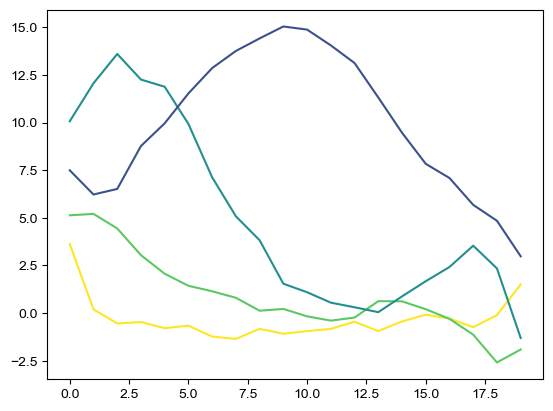

In [555]:
cmap = plt.get_cmap("viridis_r")
colors = [cmap([i]) for i in np.arange(0,1,1/4)]


labels_df = analysis.get_module_labels(config,0,1200,subgroups="all")
all_module_usage = analysis.get_module_usage(config, labels_df)
all_modules = [int(i.split("module")[1]) for i in all_module_usage.to_df().columns if "module" in i]

for g,group in enumerate(["saliv","k1iv","k5iv","k10iv"]):
    labels_df = analysis.get_module_labels(config,0,60*20,subgroups=[group])
    module_usage = analysis.get_module_usage(config, labels_df,binsize=60)
    usage_density = module_usage.usage_density(convolve=True,window=5)
    dropped = [i for i in all_modules if i not in usage_density[0].index]
    for d in usage_density:
        for drop in dropped:
            d.loc[drop] = np.zeros(usage_density[0].shape[1])
    x = []
    for item in usage_density:
        x.append(reg.predict(np.array(item,dtype=float).T))
    
    plt.plot(np.mean(x,axis=0),color=colors[g])

Labels Lasso, alpha 0.1 RMSE: 1.55


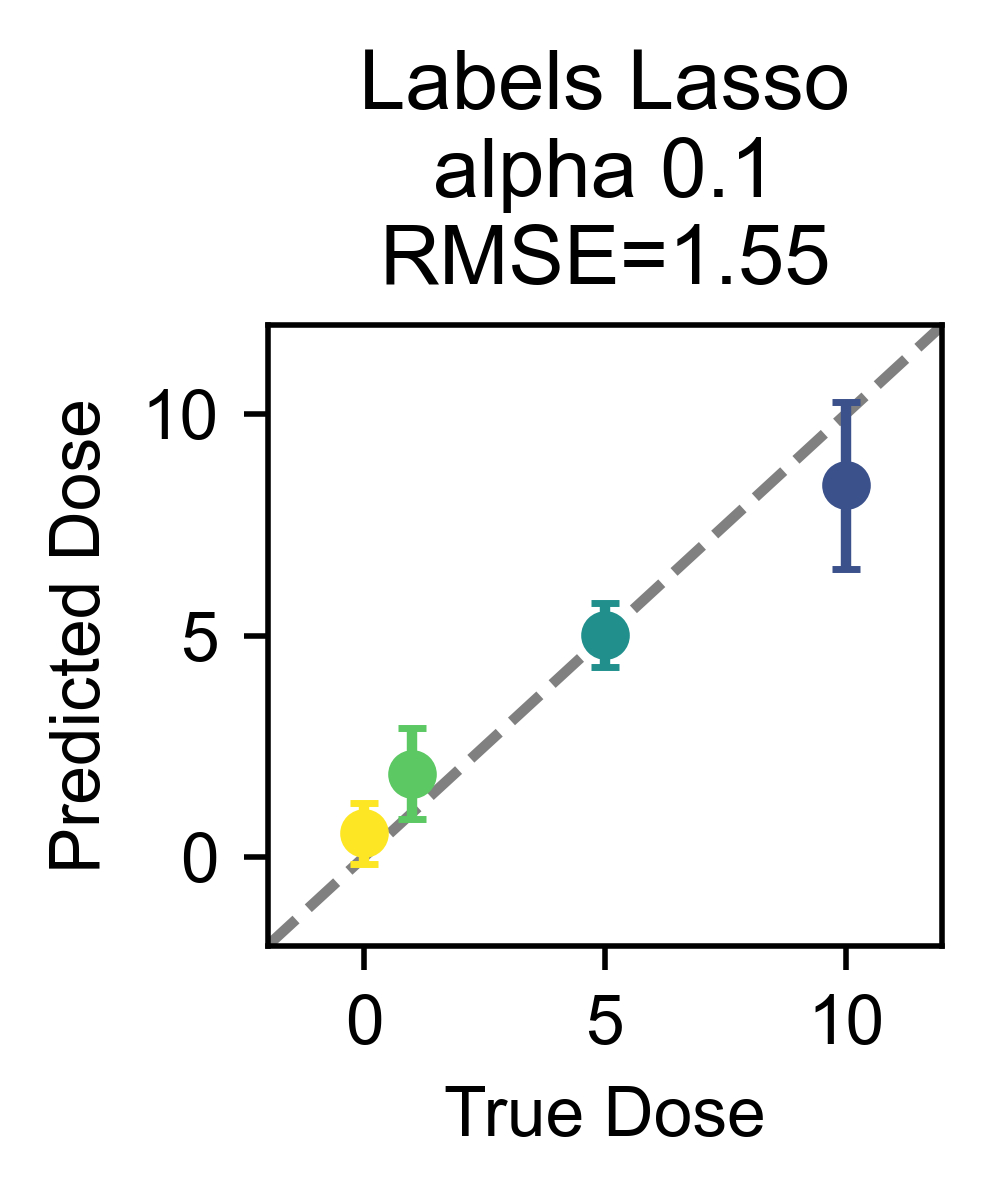

In [556]:
labels_df = analysis.get_module_labels(config,0,1200,subgroups="all")
all_module_usage = analysis.get_module_usage(config, labels_df)
all_module_usage = all_module_usage.scale()

cmap = plt.get_cmap("viridis_r")
for m,method in enumerate([["Lasso",0.1]]):
    fig = plt.figure(figsize=(2.2,2.5),dpi=500)
    plt.xlabel("True Dose")
    plt.ylabel("Predicted Dose")
    plt.ylim([-2,12])
    plt.xlim([-2,12])
    plt.axline([0,0],[1,1],linestyle="dashed",color="gray")
    reg, dose_labels = analysis.regress(all_module_usage,dose_dict,method=method[0],alpha=method[1])
    y_hat = reg.predict(all_module_usage.label_counts)
    loocv_preds, sq_err = analysis.loocv_regression(all_module_usage,dose_dict,method=method[0],alpha=method[1])
    dose_cats = np.unique(dose_labels)
    colors = [cmap([i]) for i in np.arange(0,1,1/len(dose_cats))]
    for d, do in enumerate(dose_cats):
        y_d_hat = loocv_preds[dose_labels==do]
        plt.errorbar(do,np.mean(y_d_hat),yerr=np.std(y_d_hat),marker="o",capsize=2,color=colors[d])
    rmse=np.sqrt(np.mean(sq_err))
    plt.title(f'Labels {method[0]}\nalpha {method[1]}\nRMSE={rmse:.2f}')
    print(f'Labels {method[0]}, alpha {method[1]} RMSE: {rmse:.2f}')
    plt.tight_layout()

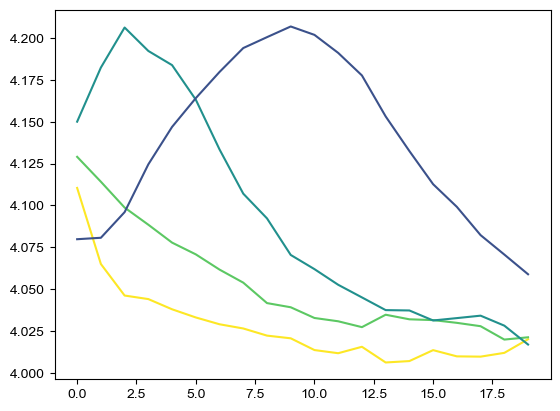

In [557]:
cmap = plt.get_cmap("viridis_r")
colors = [cmap([i]) for i in np.arange(0,1,1/4)]


labels_df = analysis.get_module_labels(config,0,1200,subgroups="all")
all_module_usage = analysis.get_module_usage(config, labels_df)
all_module_usage = all_module_usage.scale()
all_modules = [int(i.split("module")[1]) for i in all_module_usage.to_df().columns if "module" in i]

for g,group in enumerate(["saliv","k1iv","k5iv","k10iv"]):
    labels_df = analysis.get_module_labels(config,0,60*20,subgroups=[group])
    module_usage = analysis.get_module_usage(config, labels_df,binsize=60)
    usage_density = module_usage.usage_density(convolve=True,window=5)
    dropped = [i for i in all_modules if i not in usage_density[0].index]
    for d in usage_density:
        for drop in dropped:
            d.loc[drop] = np.zeros(usage_density[0].shape[1])
        d = all_module_usage.scaler.transform(d.T)
    x = []
    for item in usage_density:
        x.append(reg.predict(np.array(item,dtype=float).T))
    
    plt.plot(np.mean(x,axis=0),color=colors[g])

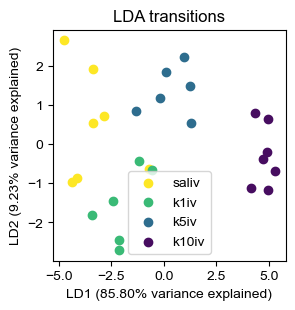

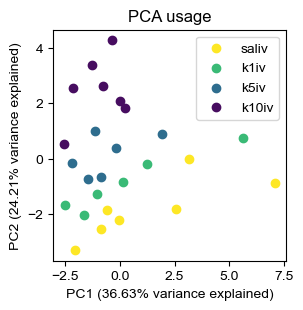

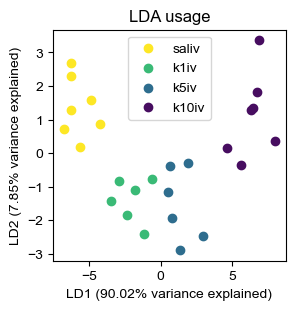

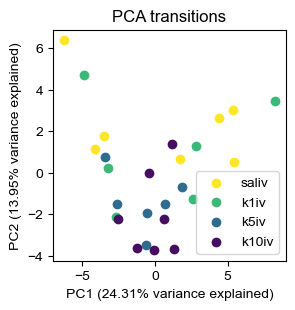

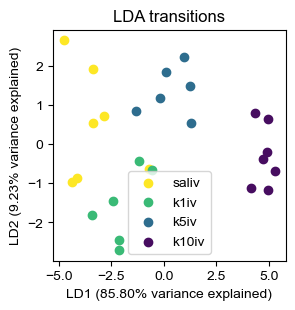

In [64]:
emb = analysis.embed(module_usage,method="PCA",n_components=2)
plot.plot_embeddings(module_usage, emb, figW=3, figH=3, cmap="viridis_r", title="PCA usage",legend=True)
    
emb = analysis.embed(module_usage,method="LDA",n_components=2)
plot.plot_embeddings(module_usage, emb, figW=3, figH=3, cmap="viridis_r", title="LDA usage",legend=True)
    
emb = analysis.embed(module_transitions,method="PCA",n_components=2)
plot.plot_embeddings(module_transitions, emb, figW=3, figH=3, cmap="viridis_r", title="PCA transitions",legend=True)
    
emb = analysis.embed(module_transitions,method="LDA",n_components=2)
plot.plot_embeddings(module_transitions, emb, figW=3, figH=3, cmap="viridis_r", title="LDA transitions",legend=True)

In [65]:
module_usage = analysis.get_module_usage(config, labels_df)
module_transitions = analysis.get_module_transitions(config, labels_df)
module_usage_scaled = module_usage.scale()
module_transitions_scaled = module_transitions.scale()

Warning - embedding (embedding=lda) without hold_out
Warning - embedding (embedding=pca) without hold_out
Warning - embedding (embedding=lda) without hold_out
Warning - embedding (embedding=pca) without hold_out
Warning - embedding (embedding=lda) without hold_out
Warning - embedding (embedding=pca) without hold_out


/Users/snewbank/PycharmProjects/MARIPoSA/utils/plot.py:286: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = plt.figure(figsize=(figW, figH))


Warning - embedding (embedding=lda) without hold_out
Warning - embedding (embedding=pca) without hold_out


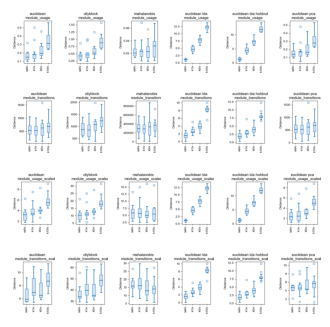

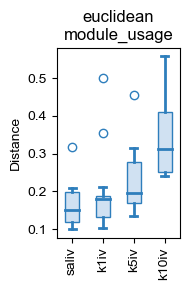

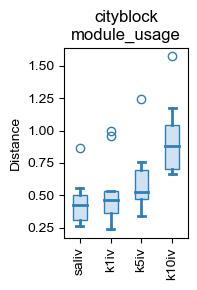

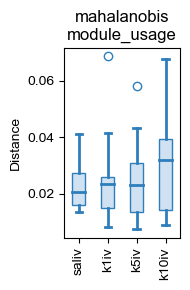

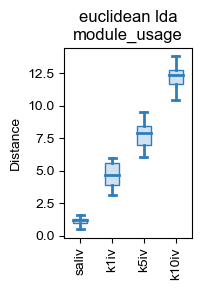

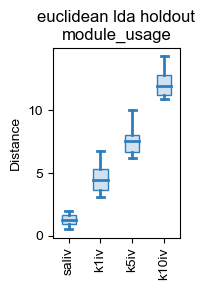

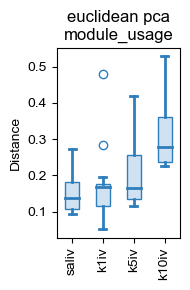

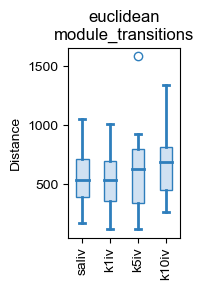

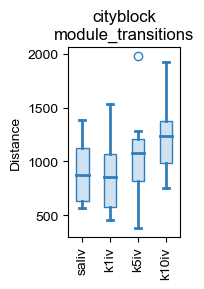

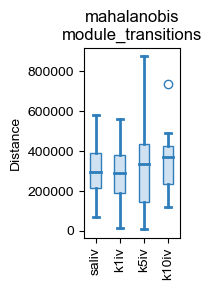

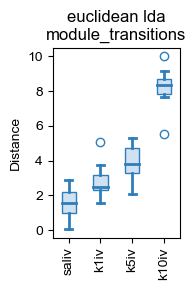

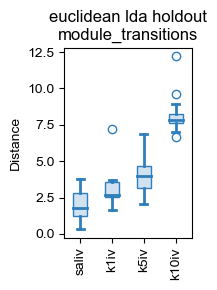

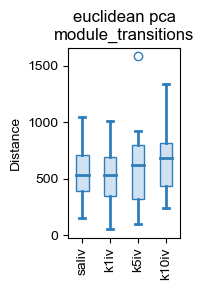

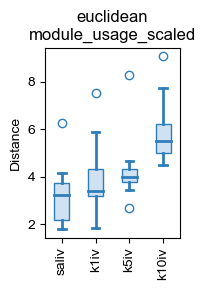

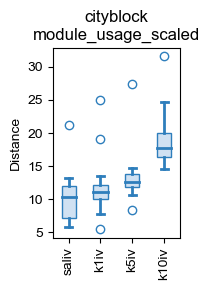

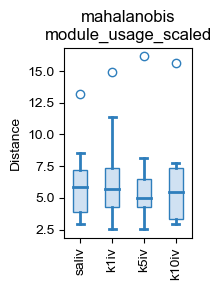

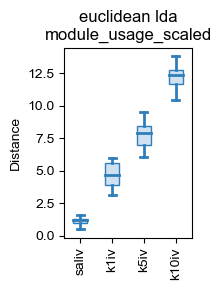

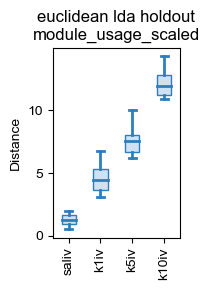

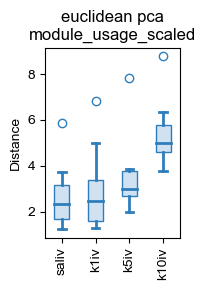

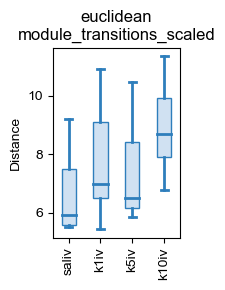

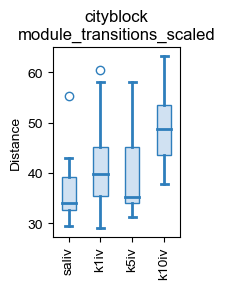

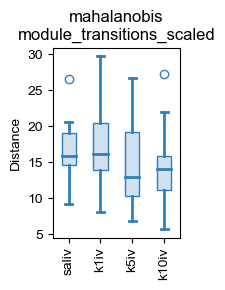

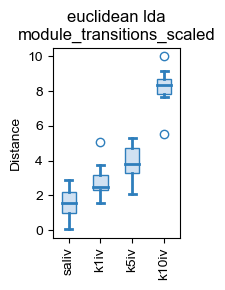

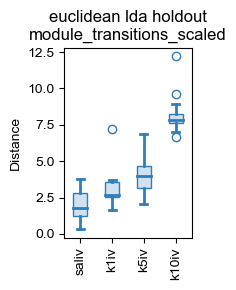

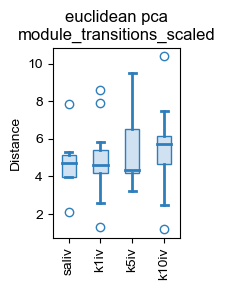

In [66]:
metrics={"module_usage":module_usage,
         "module_transitions":module_transitions,
         "module_usage_scaled":module_usage_scaled,
         "module_transitions_scaled":module_transitions_scaled}

fig_main, main_axes = plt.subplots(len(list(metrics.keys())), 6, figsize=(4, 4))

figW=2
figH=3
for m,metric in enumerate(list(metrics.keys())):
    distance_results = analysis.get_distance(metrics[metric],metric="euclidean",method="centroid")
    fig = plot.plot_distance_results(metrics[metric], distance_results,title="euclidean\n"+metric,figW=figW,figH=figH)
    im1 = plot.fig_to_array(fig)
    distance_results = analysis.get_distance(metrics[metric],metric="cityblock",method="centroid")
    fig = plot.plot_distance_results(metrics[metric], distance_results,title="cityblock\n"+metric,figW=figW,figH=figH)
    im2 = plot.fig_to_array(fig)
    distance_results = analysis.get_distance(metrics[metric],metric="mahalanobis",method="centroid")
    fig = plot.plot_distance_results(metrics[metric], distance_results,title="mahalanobis\n"+metric,figW=figW,figH=figH)
    im3 = plot.fig_to_array(fig)
    distance_results = analysis.get_distance(metrics[metric],metric="euclidean",method="centroid",embedding="lda")
    fig = plot.plot_distance_results(metrics[metric], distance_results,title="euclidean lda\n"+metric,figW=figW,figH=figH)
    im4 = plot.fig_to_array(fig)
    distance_results = analysis.get_distance(metrics[metric],metric="euclidean",method="centroid",embedding="lda",hold_out=True)
    fig = plot.plot_distance_results(metrics[metric], distance_results,title="euclidean lda holdout\n"+metric,figW=figW,figH=figH)
    im5 = plot.fig_to_array(fig)
    distance_results = analysis.get_distance(metrics[metric],metric="euclidean",method="centroid",embedding="pca")
    fig = plot.plot_distance_results(metrics[metric], distance_results,title="euclidean pca\n"+metric,figW=figW,figH=figH)
    im6 = plot.fig_to_array(fig)
    main_axes[m,0].imshow(im1)
    main_axes[m,1].imshow(im2)
    main_axes[m,2].imshow(im3)
    main_axes[m,3].imshow(im4)
    main_axes[m,4].imshow(im5)
    main_axes[m,5].imshow(im6)
    for n in range(6):
        main_axes[m,n].axis('off')

fig_main.savefig("/Users/snewbank/Desktop/grpmtg/distance.png",dpi=500)

In [68]:
emb = analysis.embed(module_usage_scaled,method="pca",n_components=4)
emb_labels = emb.transform(module_usage_scaled.label_counts)
emb = analysis.embed(module_transitions_scaled,method="pca",n_components=4)
emb_tx = emb.transform(module_transitions_scaled.transition_counts)

l2 labels silhouette: 0.0007805100075060036
l2 transitions silhouette: -0.04006526757978038
l1 labels silhouette: 0.002557855039782353
l1 transitions silhouette: -0.05779584457504938
euclidean labels silhouette: 0.0007805100075060036
euclidean transitions silhouette: -0.04006526757978038
cityblock labels silhouette: 0.002557855039782353
cityblock transitions silhouette: -0.05779584457504938
mahalanobis labels silhouette: -0.03198403158371765
mahalanobis transitions ERROR
braycurtis labels silhouette: 0.06865800363317699
braycurtis transitions silhouette: -0.02301520896264466
chebyshev labels silhouette: -0.005466954704291698
chebyshev transitions silhouette: -0.05031079739692687
hamming labels silhouette: 0.0017094017094017033
hamming transitions silhouette: -0.029918505738907773


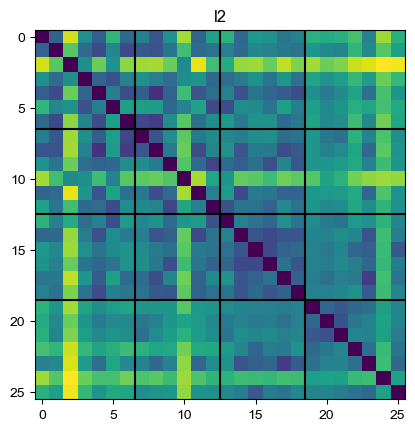

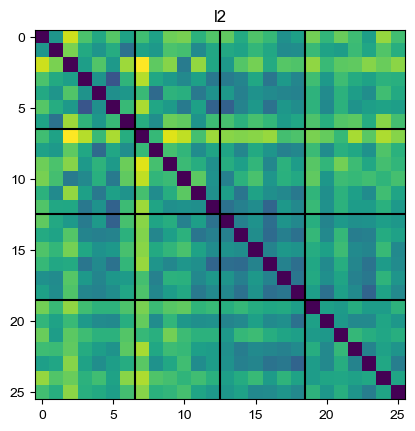

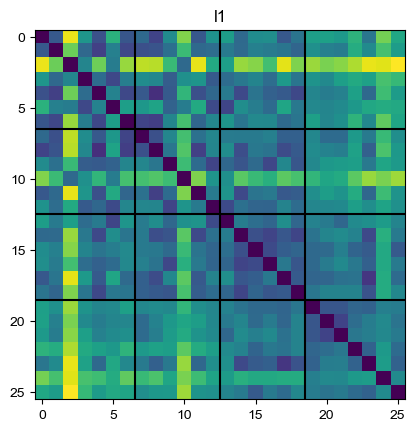

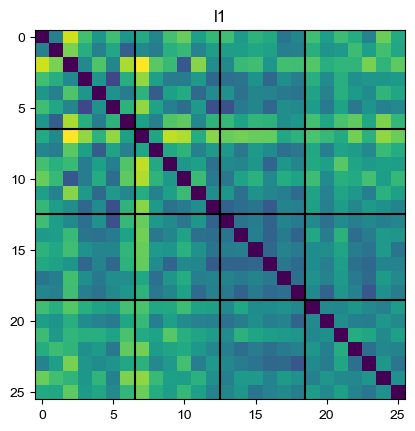

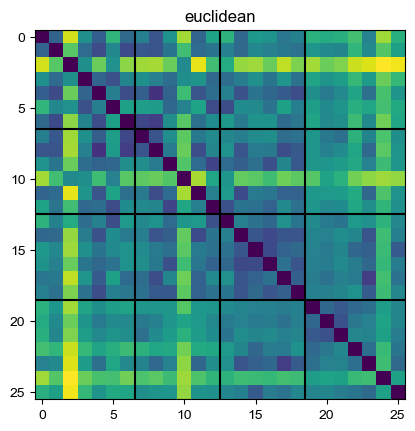

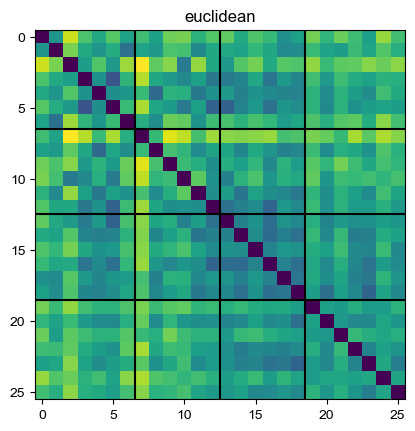

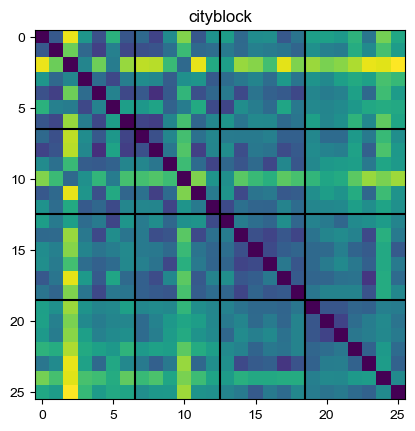

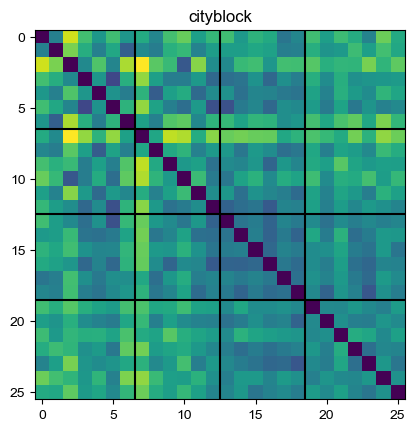

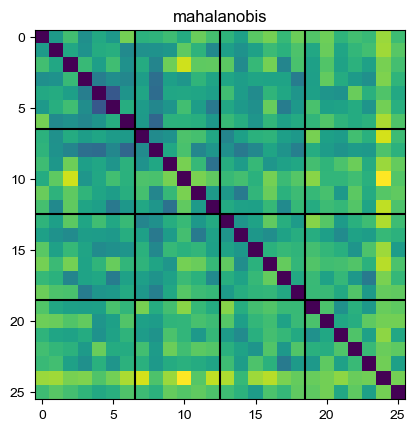

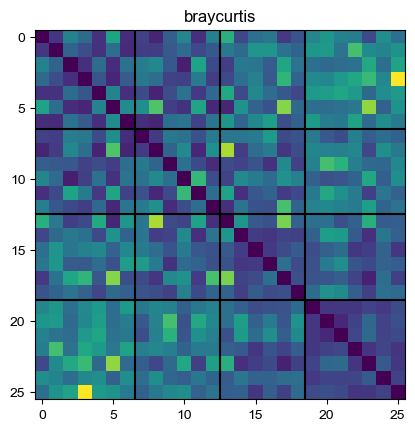

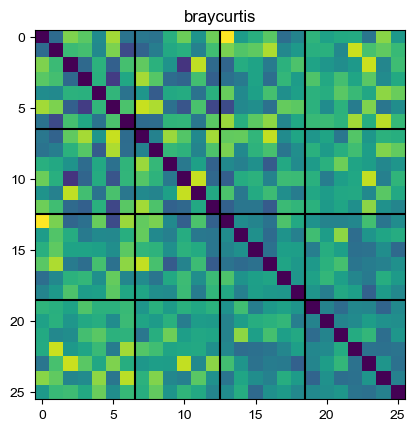

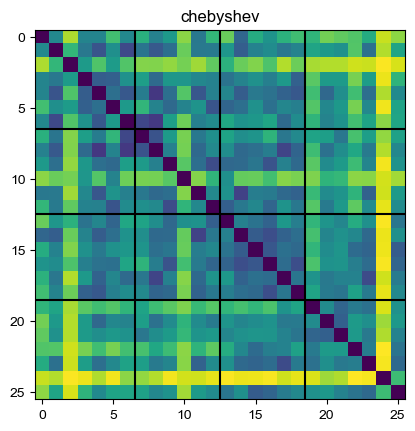

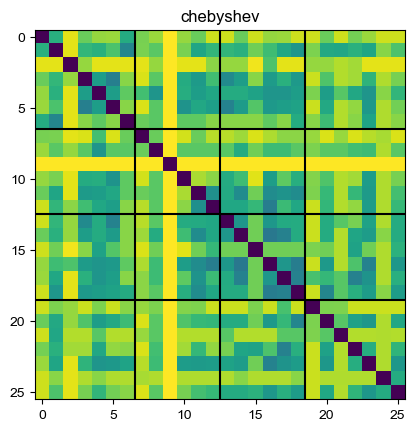

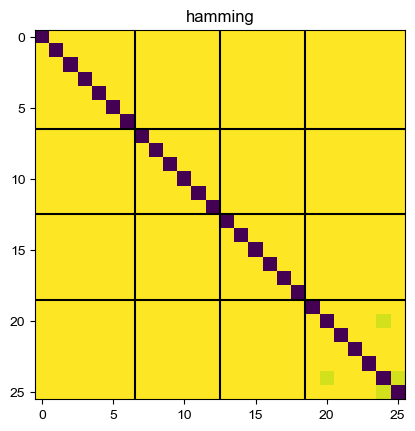

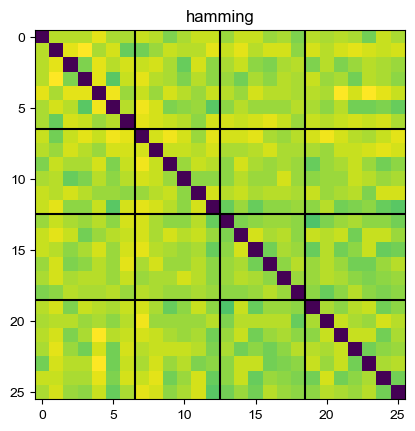

In [70]:

arr = np.array(module_usage.group_labels)
edges = np.where(arr[:-1] != arr[1:])[0]

for metric in ("l2","l1","euclidean","cityblock","mahalanobis","braycurtis","chebyshev","hamming"):
    #try:
    dist_mat = pairwise_distances(module_usage_scaled.label_counts,metric=metric)
    plt.figure()
    plt.imshow(dist_mat)
    for edge in edges:
        plt.axhline(edge+0.5,color="black")
        plt.axvline(edge+0.5,color="black")
    plt.title(metric)
    sc = silhouette_score(dist_mat,module_usage_scaled.group_labels,metric="precomputed")
    print(f'{metric} labels silhouette: {sc}')
    # except:
    #     print(f'{metric} labels ERROR')
    try:
        dist_mat = pairwise_distances(module_transitions_scaled.transition_counts,metric=metric)
        plt.figure()
        plt.imshow(dist_mat)
        for edge in edges:
            plt.axhline(edge+0.5,color="black")
            plt.axvline(edge+0.5,color="black")
        plt.title(metric)   
        sc = silhouette_score(dist_mat,module_transitions_scaled.group_labels,metric="precomputed")
        print(f'{metric} transitions silhouette: {sc}')
    except:
        print(f'{metric} transitions ERROR')

In [88]:
labels_array = np.array(module_usage.group_labels)
dist_arr = np.zeros([4,4])
for i in range(4):
    for j in range(4):
        dist_arr[i,j] = np.mean(dist_mat[labels_array==i,:][:,labels_array==j])

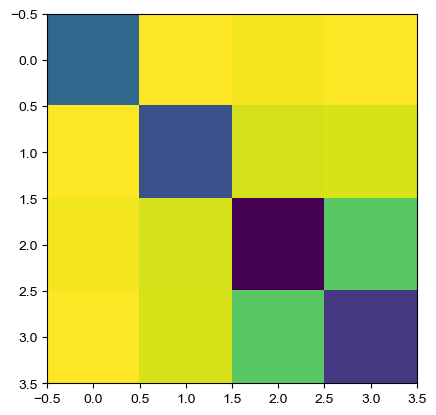

In [90]:
plt.imshow(dist_arr)